In [1]:
import netCDF4 as nc
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.animation as animation
import pandas as pd
from glob import iglob
from skimage.io import imread
import os
import seaborn as sns
import shutil
import pickle
import random
import scipy
import importlib.util
import sys
import re
from scipy.stats import gaussian_kde
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from scipy.optimize import differential_evolution
import knockpy as kpy
from knockpy.knockoff_filter import KnockoffFilter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.colors import Normalize
import itertools
from collections import defaultdict
from collections import Counter

Group 1:
  Original shape: (396, 1589760)
  Flattened shape: (629544960,)
  Value counts:
    Value 0.0: 87205032 occurrences
    Value 2.0: 76918 occurrences
    Value 3.0: 1405 occurrences
    Value 4.0: 37235795 occurrences
    Value 5.0: 677602 occurrences
    Value 6.0: 1794193 occurrences
    Value 7.0: 7557116 occurrences
    Value 8.0: 162647840 occurrences
    Value 9.0: 39594 occurrences
    Value 10.0: 162180 occurrences
    Value 11.0: 17116 occurrences
    Value 12.0: 195 occurrences
    Value 13.0: 743590 occurrences
    Value 14.0: 2841 occurrences
    Value 15.0: 774471 occurrences
    Value 16.0: 100861 occurrences
    Value 17.0: 72125 occurrences
    Value 18.0: 783020 occurrences
    Value 19.0: 60693 occurrences
    Value 20.0: 13089626 occurrences
    Value 21.0: 550561 occurrences
    Value 22.0: 2587822 occurrences
    Value 23.0: 1704306 occurrences
    Value 24.0: 14205 occurrences
    Value 25.0: 115836 occurrences
    Value 26.0: 135 occurrences
    Value 27

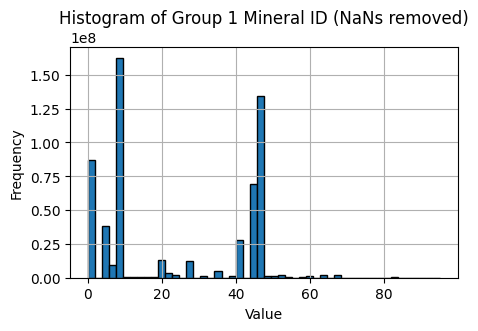

  Missing IDs in Group 1 (1..95): [1, 72, 74]
  (# missing = 3)

Group 2:
  Original shape: (396, 1589760)
  Flattened shape: (629544960,)
  Value counts:
    Value 0.0: 47469519 occurrences
    Value 96.0: 358117 occurrences
    Value 97.0: 28333006 occurrences
    Value 98.0: 2030 occurrences
    Value 99.0: 559032 occurrences
    Value 100.0: 5177455 occurrences
    Value 104.0: 7 occurrences
    Value 105.0: 758 occurrences
    Value 106.0: 46 occurrences
    Value 107.0: 89 occurrences
    Value 108.0: 15 occurrences
    Value 109.0: 6013 occurrences
    Value 111.0: 7 occurrences
    Value 112.0: 24 occurrences
    Value 113.0: 2 occurrences
    Value 115.0: 140 occurrences
    Value 116.0: 26 occurrences
    Value 117.0: 17 occurrences
    Value 118.0: 1 occurrences
    Value 119.0: 3 occurrences
    Value 122.0: 6 occurrences
    Value 124.0: 2 occurrences
    Value 125.0: 26909747 occurrences
    Value 126.0: 27506226 occurrences
    Value 127.0: 7385842 occurrences
    Value 

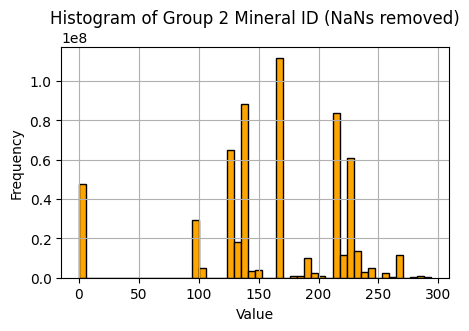

  Missing IDs in Group 2 (96..293): [101, 102, 103, 110, 114, 120, 121, 123, 149, 156, 171, 186, 249, 254, 255, 259, 261, 274, 280, 284, 285, 288, 289]
  (# missing = 23)


In [ ]:
# PREVIEW of original mineral-ID data; look at value counts, histograms, missing IDs

# === Paths ===
g1_path = '/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy'
print(g1_path.shape)
g2_path = '/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy'
print(g2_path.shape)

# --- Helper: clean uniques and counts ---
def value_counts_clean(arr_flat):
    clean = arr_flat[np.isfinite(arr_flat)]
    vals, cnts = np.unique(clean, return_counts=True)
    return clean, vals, cnts

def ids_present(arr_flat, lo, hi):
    """Return set of integer IDs in [lo, hi] present in array."""
    if arr_flat.size == 0:
        return set()
    clean = arr_flat[np.isfinite(arr_flat)]
    if clean.size == 0:
        return set()
    u = np.unique(clean)
    intlike = np.isclose(u, np.round(u))
    u_int = np.round(u[intlike]).astype(int)
    u_int = u_int[(u_int >= lo) & (u_int <= hi)]
    return set(u_int)

# ================== Group 1 ==================
gb1 = np.load(g1_path)
print("Group 1:")
print(f"  Original shape: {gb1.shape}")
gb1_flat = gb1.flatten()
print(f"  Flattened shape: {gb1_flat.shape}")

g1_clean, g1_vals, g1_counts = value_counts_clean(gb1_flat)
print("  Value counts:")
for v, c in zip(g1_vals, g1_counts):
    print(f"    Value {v}: {c} occurrences")

if g1_counts.size > 0:
    print(f"  Min count: {g1_counts.min()} (Value {g1_vals[np.argmin(g1_counts)]})")
    print(f"  Max count: {g1_counts.max()} (Value {g1_vals[np.argmax(g1_counts)]})")

# Histogram
plt.figure(figsize=(5, 3))
plt.hist(g1_clean, bins=50, edgecolor='black')
plt.title('Histogram of Group 1 Mineral ID (NaNs removed)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Missing IDs for Group 1
expected_g1 = set(range(1, 96))       # 1..95 inclusive
present_g1 = ids_present(gb1_flat, 1, 95)
missing_g1 = sorted(expected_g1 - present_g1)
print(f"  Missing IDs in Group 1 (1..95): {missing_g1}")
print(f"  (# missing = {len(missing_g1)})")

# ================== Group 2 ==================
gb2 = np.load(g2_path)
print("\nGroup 2:")
print(f"  Original shape: {gb2.shape}")
gb2_flat = gb2.flatten()
print(f"  Flattened shape: {gb2_flat.shape}")

g2_clean, g2_vals, g2_counts = value_counts_clean(gb2_flat)
print("  Value counts:")
for v, c in zip(g2_vals, g2_counts):
    print(f"    Value {v}: {c} occurrences")

if g2_counts.size > 0:
    print(f"  Min count: {g2_counts.min()} (Value {g2_vals[np.argmin(g2_counts)]})")
    print(f"  Max count: {g2_counts.max()} (Value {g2_vals[np.argmax(g2_counts)]})")

# Histogram
plt.figure(figsize=(5, 3))
plt.hist(g2_clean, bins=50, edgecolor='black', color='orange')
plt.title('Histogram of Group 2 Mineral ID (NaNs removed)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Missing IDs for Group 2
expected_g2 = set(range(96, 294))     # 96..293 inclusive
present_g2 = ids_present(gb2_flat, 96, 293)
missing_g2 = sorted(expected_g2 - present_g2)
print(f"  Missing IDs in Group 2 (96..293): {missing_g2}")
print(f"  (# missing = {len(missing_g2)})")


(581546628, 2)
All observed (g1, g2) mineral-ID pairs sorted by count:
(0, 0) -> 33490096
(8, 139) -> 31471145
(8, 168) -> 30659693
(0, 97) -> 23606161
(46, 168) -> 20718796
(8, 141) -> 16547522
(8, 215) -> 13708644
(46, 139) -> 12442004
(4, 168) -> 11453135
(45, 215) -> 10708912
(8, 166) -> 9054873
(45, 139) -> 8910081
(46, 125) -> 8067081
(45, 168) -> 8003291
(8, 125) -> 7100343
(40, 215) -> 6966699
(46, 166) -> 6800928
(8, 227) -> 6430325
(28, 215) -> 6296856
(0, 215) -> 6174451
(46, 215) -> 5623521
(8, 126) -> 5458547
(8, 216) -> 5328202
(45, 226) -> 5144677
(8, 226) -> 4635661
(47, 232) -> 4528141
(45, 227) -> 4248568
(46, 126) -> 4104294
(4, 215) -> 3834644
(46, 225) -> 3803762
(47, 97) -> 3649545
(47, 227) -> 3641050
(8, 167) -> 3561918
(4, 126) -> 3544842
(46, 227) -> 3518260
(8, 213) -> 3492275
(4, 139) -> 3478071
(45, 126) -> 3453137
(0, 228) -> 3260868
(45, 125) -> 3203127
(0, 265) -> 3102575
(4, 125) -> 3099209
(4, 166) -> 3050581
(47, 215) -> 2857578
(47, 126) -> 2852088
(

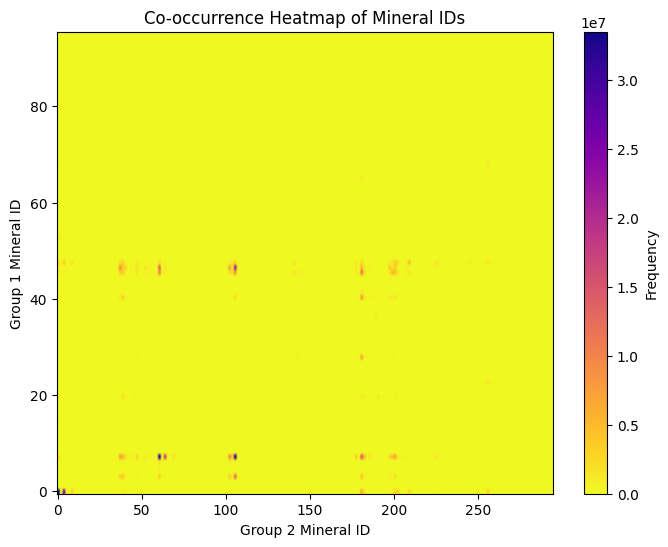

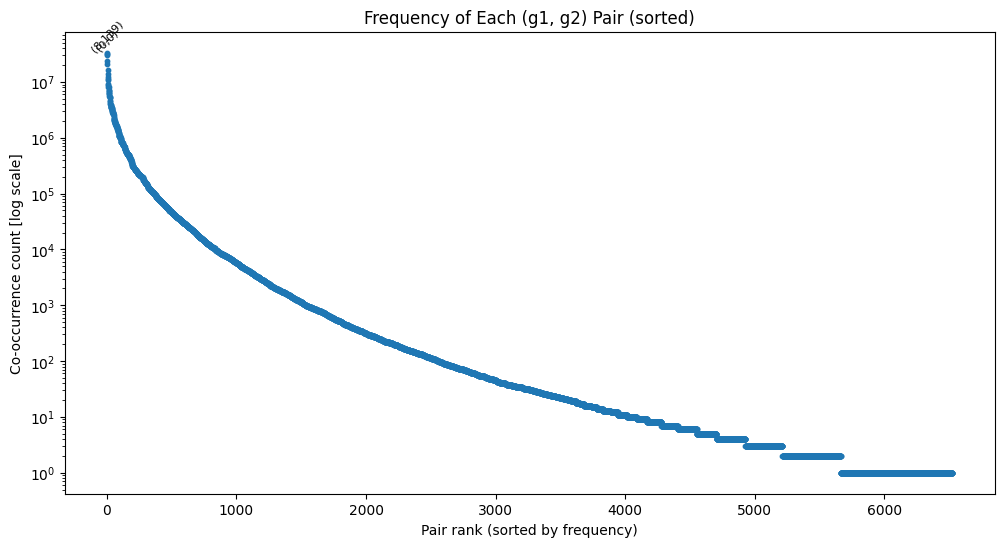

In [19]:
#see which group IDs occur together in the original data; plot heatmap of co-occurrence frequencies and scatter of counts

# --- Build (g1, g2) pairs from your sampled data ---
pairs = np.vstack((g1_clean, g2_clean)).T
print(pairs.shape)

# Remove rows with NaNs
mask_finite = np.isfinite(pairs).all(axis=1)
pairs_clean = np.rint(pairs[mask_finite]).astype(int)

# --- Count co-occurrences ---
pair_counts = Counter(map(tuple, pairs_clean))

# === Sorted by decreasing frequency ===
sorted_pairs = pair_counts.most_common()

print("All observed (g1, g2) mineral-ID pairs sorted by count:")
for (id1, id2), count in sorted_pairs:
    print(f"({id1}, {id2}) -> {count}")

# --- Heatmap (all pairs still included) ---
g1_ids = sorted({p[0] for p in pair_counts})
g2_ids = sorted({p[1] for p in pair_counts})
row_index = {v: i for i, v in enumerate(g1_ids)}
col_index = {v: j for j, v in enumerate(g2_ids)}

heatmap = np.zeros((len(g1_ids), len(g2_ids)), dtype=int)
for (id1, id2), c in pair_counts.items():
    heatmap[row_index[id1], col_index[id2]] = c

plt.figure(figsize=(8, 6))
im = plt.imshow(
    heatmap, cmap="plasma_r", origin="lower",
    extent=[g2_ids[0]-0.5, g2_ids[-1]+0.5,
            g1_ids[0]-0.5, g1_ids[-1]+0.5],
    aspect='auto'
)
cbar = plt.colorbar(im)
cbar.set_label("Frequency")
plt.xlabel("Group 2 Mineral ID")
plt.ylabel("Group 1 Mineral ID")
plt.title("Co-occurrence Heatmap of Mineral IDs")
plt.grid(False)
plt.show()

# --- Scatter plot with labels for top 20 pairs ---
sorted_pairs = sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)
pairs = [f"({p[0]},{p[1]})" for p, _ in sorted_pairs]
freqs = [c for _, c in sorted_pairs]

plt.figure(figsize=(12, 6))
plt.scatter(range(len(freqs)), freqs, s=10, color="tab:blue")
plt.yscale("log")
plt.xlabel("Pair rank (sorted by frequency)")
plt.ylabel("Co-occurrence count [log scale]")
plt.title("Frequency of Each (g1, g2) Pair (sorted)")

# Label the top 20 pairs
TOP_N = 2
for i, (label, count) in enumerate(zip(pairs[:TOP_N], freqs[:TOP_N])):
    plt.text(i, count, label, fontsize=8, ha="center", va="bottom", rotation=45)

plt.show()



Top 10 most common nonzero mineral-ID pairs (g1, g2):
(8, 139) -> 31471145
(8, 168) -> 30659693
(46, 168) -> 20718796
(8, 141) -> 16547522
(8, 215) -> 13708644
(46, 139) -> 12442004
(4, 168) -> 11453135
(45, 215) -> 10708912
(8, 166) -> 9054873
(45, 139) -> 8910081


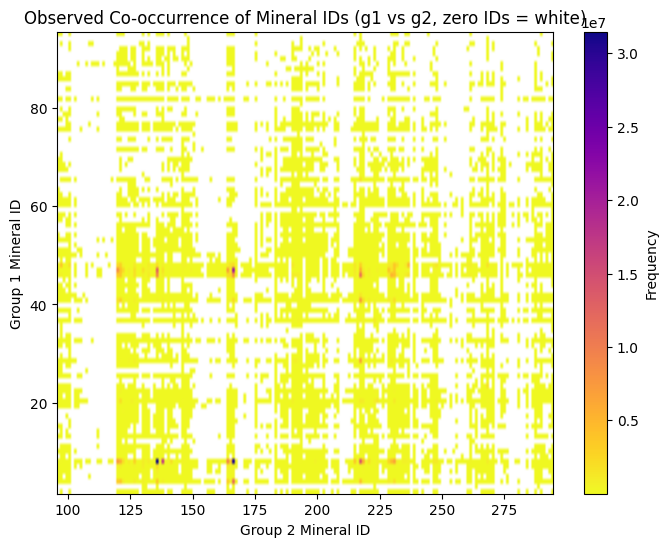

In [9]:
#see which group IDs occur together in the original data (no zero IDs)

# --- Build (g1, g2) pairs from your sampled data ---
pairs = np.vstack((g1_clean, g2_clean)).T

# Remove rows with NaNs
mask_finite = np.isfinite(pairs).all(axis=1)
pairs_clean = pairs[mask_finite]

# Optionally guard against float IDs due to earlier ops; round to nearest int
pairs_clean = np.rint(pairs_clean).astype(int)

# === EXCLUDE any pair with a zero ID ===
nonzero_mask = (pairs_clean[:, 0] != 0) & (pairs_clean[:, 1] != 0)
pairs_nz = pairs_clean[nonzero_mask]

# Safety check: no zeros remain
# assert not ((pairs_nz == 0).any(axis=1)).any()

# --- Count co-occurrences ---
pair_counts = Counter(map(tuple, pairs_nz))
most_common_pairs = pair_counts.most_common(10)

print("Top 10 most common nonzero mineral-ID pairs (g1, g2):")
for (id1, id2), count in most_common_pairs:
    print(f"({id1}, {id2}) -> {count}")

# --- Build compact matrix only for observed IDs (nonzero only) ---
g1_ids = sorted({p[0] for p in pair_counts})
g2_ids = sorted({p[1] for p in pair_counts})
row_index = {v: i for i, v in enumerate(g1_ids)}
col_index = {v: j for j, v in enumerate(g2_ids)}

heatmap = np.zeros((len(g1_ids), len(g2_ids)), dtype=int)
for (id1, id2), c in pair_counts.items():
    heatmap[row_index[id1], col_index[id2]] = c

# pick a reversed colormap so higher values are darker/stronger
cmap = plt.cm.plasma_r.copy()   
cmap.set_under('white')   # force zeros (below vmin) to be pure white

plt.figure(figsize=(8, 6))
im = plt.imshow(
    heatmap, cmap=cmap, origin="lower",
    extent=[g2_ids[0]-0.5, g2_ids[-1]+0.5,
            g1_ids[0]-0.5, g1_ids[-1]+0.5],
    aspect='auto', vmin=1   # vmin=1 ensures 0 values are treated as "under"
)

# add the colorbar linked to the image
cbar = plt.colorbar(im)
cbar.set_label("Frequency")

plt.xlabel("Group 2 Mineral ID")
plt.ylabel("Group 1 Mineral ID")
plt.title("Observed Co-occurrence of Mineral IDs (g1 vs g2, zero IDs = white)")
plt.grid(False)
plt.show()






In [ ]:
# Sample generation with per-ID minimum and "at least one" guarantee; change MIN_PER_ID as needed
#USED THIS SCRIPT FOR DISSERTATION REFerence

# === Config ===
SEED = 42
MIN_PER_ID = 7500          # target per-ID; change as needed
SAVE_PATH = '../Data/balanced_g1_g2_indices_MINperID_7500.npy'

np.random.seed(SEED)  # reproducibility for np.random.shuffle

# === Load & flatten ===
g1 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy').flatten()
g2 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy').flatten()

valid_g1_idx = np.where(~np.isnan(g1))[0]
valid_g2_idx = np.where(~np.isnan(g2))[0]

print(f"Group 1 valid indices: {len(valid_g1_idx)}")
print(f"Group 2 valid indices: {len(valid_g2_idx)}")

# === Helper: sample per ID with at-least-one guarantee ===
def sample_group(values, valid_idx, exclude_indices=None, min_per_id=MIN_PER_ID):
    """
    For each existing ID in 'values' at positions 'valid_idx', sample indices:
      - target = min_per_id per ID, but never more than available
      - guarantee at least 1 per ID if available (even if target < 1)
      - optionally exclude 'exclude_indices' (e.g., to keep g1 & g2 disjoint)
    Returns: sampled_indices (np.array), per_id_counts (Counter), shortfall_ids (list)
    """
    if exclude_indices is None:
        exclude_indices = set()

    sampled = []
    per_id_counts = Counter()
    shortfall_ids = []  # IDs that could not reach min_per_id (took all available)

    uniq_ids = np.unique(values[valid_idx])
    # drop NaN if it slipped through
    uniq_ids = uniq_ids[~np.isnan(uniq_ids)]

    for v in uniq_ids:
        pool = valid_idx[values[valid_idx] == v]
        # exclude already-used indices
        if exclude_indices:
            pool = np.setdiff1d(pool, list(exclude_indices), assume_unique=False)

        avail = pool.size
        if avail == 0:
            # nothing available after exclusions
            shortfall_ids.append((v, 0, min_per_id))
            continue

        # target with "at least one" guarantee
        target = min(avail, max(1, min_per_id))

        pool_shuf = pool.copy()
        np.random.shuffle(pool_shuf)
        take = pool_shuf[:target]

        sampled.extend(take.tolist())
        per_id_counts[v] = target

        if target < min_per_id:
            shortfall_ids.append((v, target, min_per_id))

    return np.array(sampled, dtype=int), per_id_counts, shortfall_ids

# === Pass 1: sample Group 1 per-ID ===
g1_indices, g1_counts, g1_short = sample_group(g1, valid_g1_idx, exclude_indices=None, min_per_id=MIN_PER_ID)
used = set(g1_indices.tolist())

# === Pass 2: sample Group 2 per-ID, excluding g1's picks ===
g2_indices, g2_counts, g2_short = sample_group(g2, valid_g2_idx, exclude_indices=used, min_per_id=MIN_PER_ID)

# === Merge & save ===
merged_indices = np.unique(np.concatenate([g1_indices, g2_indices]))
np.save(SAVE_PATH, merged_indices)

print("\n=== Sampling summary ===")
print(f"Saved merged indices: {len(merged_indices)}  ->  {SAVE_PATH}")
print(f"G1 sampled: {len(g1_indices)} indices across {len(g1_counts)} IDs")
print(f"G2 sampled: {len(g2_indices)} indices across {len(g2_counts)} IDs")
print(f"Overlap (should be 0): {len(set(g1_indices) & set(g2_indices))}")

# === Diagnostics: per-ID min/max & at-least-one checks ===
if g1_counts:
    print("\nGroup 1 per-ID counts:")
    print(f"  Min per-ID count: {min(g1_counts.values())}")
    print(f"  Max per-ID count: {max(g1_counts.values())}")
    # ensure every existing ID got at least one
    g1_existing_ids = set(np.unique(g1[valid_g1_idx])) - {np.nan}
    g1_existing_ids = {int(x) for x in g1_existing_ids if np.isfinite(x) and np.isclose(x, round(x))}
    g1_sampled_ids = {int(x) for x in g1_counts.keys()}
    missing_any_g1 = sorted(g1_existing_ids - g1_sampled_ids)
    print(f"  IDs with no sample (should be []): {missing_any_g1}")

if g2_counts:
    print("\nGroup 2 per-ID counts:")
    print(f"  Min per-ID count: {min(g2_counts.values())}")
    print(f"  Max per-ID count: {max(g2_counts.values())}")
    g2_existing_ids = set(np.unique(g2[valid_g2_idx])) - {np.nan}
    g2_existing_ids = {int(x) for x in g2_existing_ids if np.isfinite(x) and np.isclose(x, round(x))}
    g2_sampled_ids = {int(x) for x in g2_counts.keys()}
    missing_any_g2 = sorted(g2_existing_ids - g2_sampled_ids)
    print(f"  IDs with no sample (should be []): {missing_any_g2}")

# === Report which IDs fell short of the target MIN_PER_ID (took all available instead) ===
def summarize_shortfalls(short_list, label):
    if not short_list:
        print(f"\n{label}: all IDs met MIN_PER_ID={MIN_PER_ID}.")
        return
    print(f"\n{label}: IDs that fell short of MIN_PER_ID={MIN_PER_ID} (took available < target):")
    # short_list items are tuples (id_value, taken, target)
    # sort by how short they were
    short_sorted = sorted(short_list, key=lambda t: (t[2] - t[1], t[0]), reverse=True)
    # print top few; comment out the slice to print all
    for v, taken, target in short_sorted[:20]:
        print(f"  ID {v}: took {taken} / target {target}")

summarize_shortfalls(g1_short, "Group 1 shortfalls")
summarize_shortfalls(g2_short, "Group 2 shortfalls")


Group 1 valid indices: 581546628
Group 2 valid indices: 581546628

=== Sampling summary ===
Saved merged indices: 1260203  ->  ../Data/balanced_g1_g2_indices_MINperID_7500.npy
G1 sampled: 505430 indices across 93 IDs
G2 sampled: 754773 indices across 177 IDs
Overlap (should be 0): 0

Group 1 per-ID counts:
  Min per-ID count: 1
  Max per-ID count: 7500
  IDs with no sample (should be []): []

Group 2 per-ID counts:
  Min per-ID count: 1
  Max per-ID count: 7500
  IDs with no sample (should be []): []

Group 1 shortfalls: IDs that fell short of MIN_PER_ID=7500 (took available < target):
  ID 83.0: took 1 / target 7500
  ID 94.0: took 15 / target 7500
  ID 63.0: took 71 / target 7500
  ID 58.0: took 91 / target 7500
  ID 34.0: took 105 / target 7500
  ID 81.0: took 108 / target 7500
  ID 35.0: took 116 / target 7500
  ID 26.0: took 135 / target 7500
  ID 12.0: took 195 / target 7500
  ID 71.0: took 218 / target 7500
  ID 93.0: took 289 / target 7500
  ID 91.0: took 299 / target 7500
  ID

(717830,)
Original g1 shape: (629544960,)
Original g2 shape: (629544960,)
Loaded index count: 717830


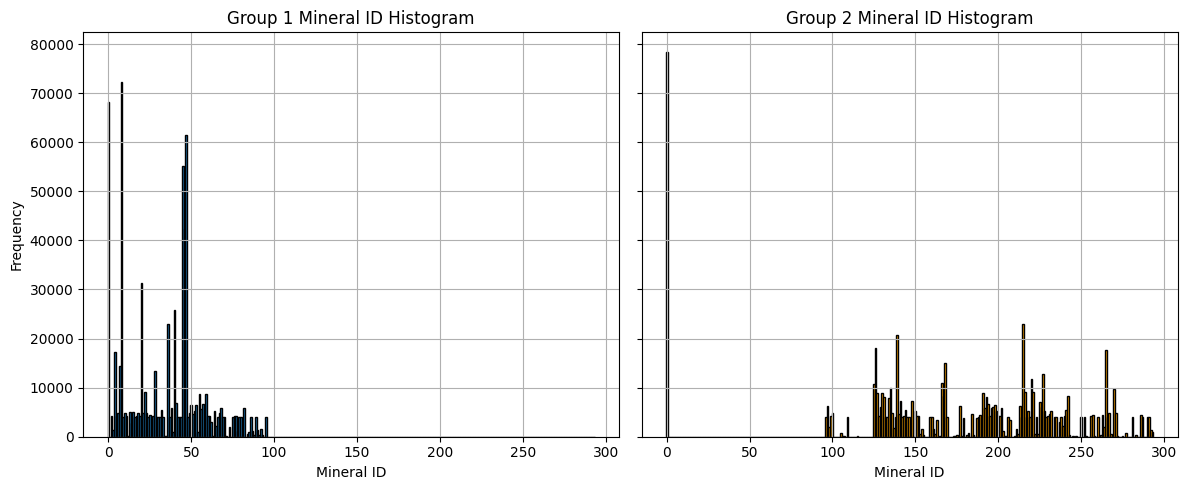

Group 1: 717830 values, 0 NaNs removed
Group 2: 717830 values, 0 NaNs removed


In [2]:
#resulting data distribution after collecting pixel-level mineral-ID values at sampled indices

# === Load datasets ===
g1 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy').flatten()
g2 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy').flatten()
indices = np.load('../Data/balanced_g1_g2_indices_MINperID_4000.npy') #change path as needed for different sample sets
print(indices.shape)

print("Original g1 shape:", g1.shape)
print("Original g2 shape:", g2.shape)
print("Loaded index count:", len(indices))

# === Extract values at sampled indices ===
g1_vals = g1[indices]
g2_vals = g2[indices]

# === Remove NaNs ===
g1_clean = g1_vals[~np.isnan(g1_vals)]
g2_clean = g2_vals[~np.isnan(g2_vals)]

# === Determine consistent bins for comparison ===
all_vals = np.concatenate((g1_clean, g2_clean))
bins = np.arange(np.floor(all_vals.min()), np.ceil(all_vals.max()) + 1) - 0.5

# === Plot histograms side-by-side ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(g1_clean, bins=bins, edgecolor='black')
axes[0].set_title('Group 1 Mineral ID Histogram')
axes[0].set_xlabel('Mineral ID')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

axes[1].hist(g2_clean, bins=bins, edgecolor='black', color='orange')
axes[1].set_title('Group 2 Mineral ID Histogram')
axes[1].set_xlabel('Mineral ID')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# === Optional: Print summary ===
print(f"Group 1: {len(g1_clean)} values, {np.isnan(g1_vals).sum()} NaNs removed")
print(f"Group 2: {len(g2_clean)} values, {np.isnan(g2_vals).sum()} NaNs removed")




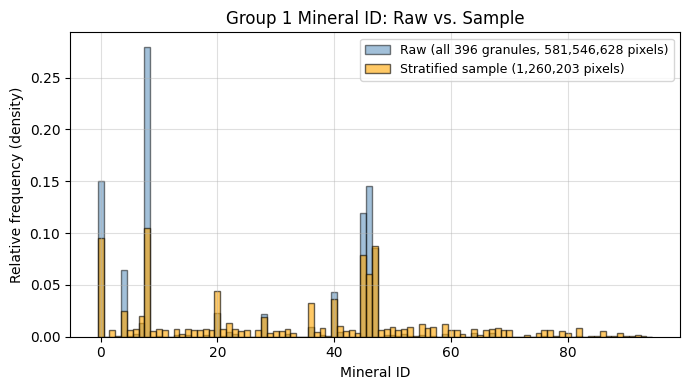

Raw Group 1:      581,546,628 pixels
Sampled Group 1:    1,260,203 pixels
Sampling ratio:  0.2167%

  ID  Mineral                                                             Raw     Sampled
------------------------------------------------------------------------------------------
   8  Goethite_Thin_Film WS222 W1R1Ba                             162,647,840     131,922
   0  Unclassified                                                 87,205,032     119,229
  46  nHematit+fg-Goethit 34B2+MPC W1R1Hb                          84,794,905      76,338
  45  Nanohematite BR93-34B2 W1R1BbS                               69,624,616      98,940
  47  Nanohematite FBR93-34B2b ed1 W1R1Hb                          49,689,481     109,428
   4  Goethite0.02+Quartz GDS240 W1R1Ba                            37,235,795      30,900
  40  Basalt_weathered BR93-43 W1R1Bb                              25,263,356      45,183
  20  Cummingtonite HS294.3B W1R1Bc                                13,089,626      55,412

In [14]:
# === Compare raw vs. sampled Group 1 distributions on a single plot ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the full Group 1 dataset (all 396 granules)
g1_raw = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy').flatten()
g1_raw_clean = g1_raw[np.isfinite(g1_raw)]

# Load the sampled indices and extract sampled values
indices = np.load('../Data/balanced_g1_g2_indices_MINperID_7500.npy')
g1_sampled = g1_raw[indices]
g1_sampled_clean = g1_sampled[~np.isnan(g1_sampled)]

# === Common bin edges so both histograms align on the same x-axis ===
all_vals = np.concatenate((g1_raw_clean, g1_sampled_clean))
bins = np.arange(np.floor(all_vals.min()), np.ceil(all_vals.max()) + 1) - 0.5

# === Overlay plot, normalized to relative frequency ===
plt.figure(figsize=(7, 4))
plt.hist(g1_raw_clean, bins=bins, density=True,
         alpha=0.5, color='steelblue', edgecolor='black',
         label=f'Raw (all 396 granules, {len(g1_raw_clean):,} pixels)')
plt.hist(g1_sampled_clean, bins=bins, density=True,
         alpha=0.6, color='orange', edgecolor='black',
         label=f'Stratified sample ({len(g1_sampled_clean):,} pixels)')
plt.title('Group 1 Mineral ID: Raw vs. Sample')
plt.xlabel('Mineral ID')
plt.ylabel('Relative frequency (density)')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('G1_hist_raw_vs_sampled.png', dpi=150, bbox_inches='tight')
plt.show()

# === Summary ===
print(f"Raw Group 1:     {len(g1_raw_clean):>12,} pixels")
print(f"Sampled Group 1: {len(g1_sampled_clean):>12,} pixels")
print(f"Sampling ratio:  {len(g1_sampled_clean) / len(g1_raw_clean) * 100:.4f}%")

# === Per-mineral counts for both raw and stratified sample ===
# Load mineral grouping matrix to get human-readable names
mgm = pd.read_csv('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/mineral_grouping_matrix_20230503.csv')
id_to_name = dict(zip(mgm['Index'].astype(int), mgm['Name']))
id_to_name[0] = 'Unclassified'  # ID 0 isn't in the matrix

# Count occurrences in each set
raw_ids,     raw_counts     = np.unique(g1_raw_clean.astype(int),     return_counts=True)
sampled_ids, sampled_counts = np.unique(g1_sampled_clean.astype(int), return_counts=True)

raw_dict     = dict(zip(raw_ids,     raw_counts))
sampled_dict = dict(zip(sampled_ids, sampled_counts))

# Union of all IDs that appear anywhere
all_ids = sorted(set(raw_dict.keys()) | set(sampled_dict.keys()))

# Build a tidy table
rows = []
for mid in all_ids:
    rows.append({
        'ID':       mid,
        'Mineral':  id_to_name.get(mid, '(unknown)'),
        'Raw':      raw_dict.get(mid, 0),
        'Sampled':  sampled_dict.get(mid, 0),
    })
df = pd.DataFrame(rows)

# Print a readable, sorted-by-raw-count summary
df_sorted = df.sort_values('Raw', ascending=False).reset_index(drop=True)

print(f"\n{'ID':>4}  {'Mineral':<55}  {'Raw':>14}  {'Sampled':>10}")
print('-' * 90)
for _, r in df_sorted.iterrows():
    name = r['Mineral'] if len(str(r['Mineral'])) <= 55 else str(r['Mineral'])[:52] + '...'
    print(f"{r['ID']:>4}  {name:<55}  {r['Raw']:>14,}  {r['Sampled']:>10,}")

# Save as CSV for downstream use
df_sorted.to_csv('G1_per_mineral_counts.csv', index=False)
print(f"\nSaved per-mineral counts to G1_per_mineral_counts.csv ({len(df_sorted)} rows)")


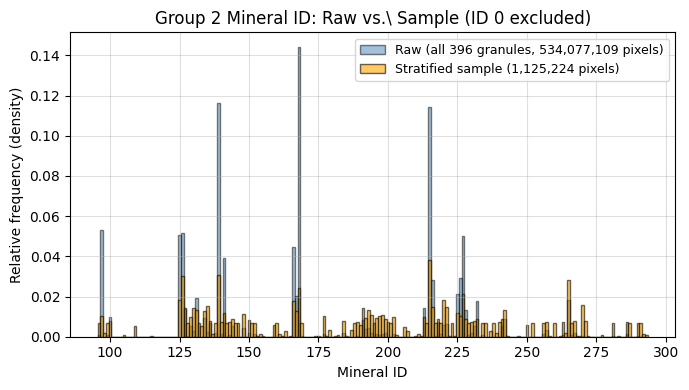

Raw Group 2     (incl. ID 0):  581,546,628 pixels
Raw Group 2     (excl. ID 0):  534,077,109 pixels
Sampled Group 2 (incl. ID 0):    1,260,203 pixels
Sampled Group 2 (excl. ID 0):    1,125,224 pixels
ID 0 fraction (raw):     8.16%
ID 0 fraction (sampled): 10.71%


In [13]:
# === Compare raw vs. sampled Group 2 distributions on a single plot (excluding ID 0) ===

# Load the full Group 2 dataset (all 396 granules)
g2_raw = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy').flatten()
g2_raw_clean = g2_raw[np.isfinite(g2_raw)]

# Load the sampled indices and extract sampled values
indices = np.load('../Data/balanced_g1_g2_indices_MINperID_7500.npy')
g2_sampled = g2_raw[indices]
g2_sampled_clean = g2_sampled[~np.isnan(g2_sampled)]

# === Exclude ID 0 (unclassified) from both distributions ===
g2_raw_nz     = g2_raw_clean[g2_raw_clean != 0]
g2_sampled_nz = g2_sampled_clean[g2_sampled_clean != 0]

# === Common bin edges so both histograms align on the same x-axis ===
all_vals = np.concatenate((g2_raw_nz, g2_sampled_nz))
bins = np.arange(np.floor(all_vals.min()), np.ceil(all_vals.max()) + 1) - 0.5

# === Overlay plot, normalized to relative frequency ===
plt.figure(figsize=(7, 4))
plt.hist(g2_raw_nz, bins=bins, density=True,
         alpha=0.5, color='steelblue', edgecolor='black',
         label=f'Raw (all 396 granules, {len(g2_raw_nz):,} pixels)')
plt.hist(g2_sampled_nz, bins=bins, density=True,
         alpha=0.6, color='orange', edgecolor='black',
         label=f'Stratified sample ({len(g2_sampled_nz):,} pixels)')
plt.title('Group 2 Mineral ID: Raw vs.\\ Sample (ID 0 excluded)')
plt.xlabel('Mineral ID')
plt.ylabel('Relative frequency (density)')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('G2_orig_samphist.png', dpi=150, bbox_inches='tight')
plt.show()

# === Summary ===
print(f"Raw Group 2     (incl. ID 0): {len(g2_raw_clean):>12,} pixels")
print(f"Raw Group 2     (excl. ID 0): {len(g2_raw_nz):>12,} pixels")
print(f"Sampled Group 2 (incl. ID 0): {len(g2_sampled_clean):>12,} pixels")
print(f"Sampled Group 2 (excl. ID 0): {len(g2_sampled_nz):>12,} pixels")
print(f"ID 0 fraction (raw):     {(len(g2_raw_clean) - len(g2_raw_nz)) / len(g2_raw_clean) * 100:.2f}%")
print(f"ID 0 fraction (sampled): {(len(g2_sampled_clean) - len(g2_sampled_nz)) / len(g2_sampled_clean) * 100:.2f}%")


Train shape: (717830, 289)
(56, 270) -> 4890
(0, 0) -> 4451
(23, 265) -> 4373
(0, 97) -> 4373
(75, 0) -> 3982
(15, 0) -> 3881
(0, 109) -> 3818
(66, 0) -> 3817
(9, 0) -> 3782
(52, 0) -> 3778
(24, 0) -> 3708
(7, 235) -> 3602
(8, 141) -> 3593
(0, 250) -> 3554
(69, 0) -> 3513
(79, 0) -> 3477
(0, 96) -> 3456
(31, 0) -> 3380
(0, 238) -> 3347
(43, 0) -> 3191


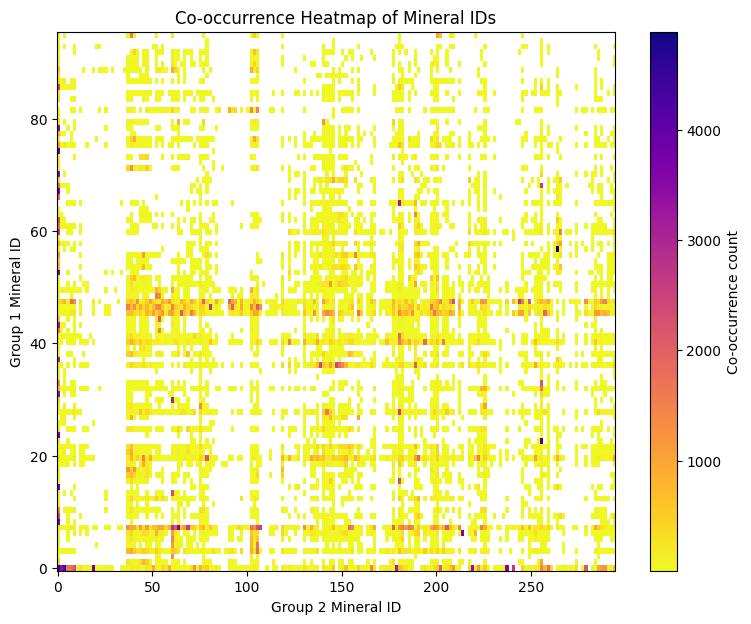

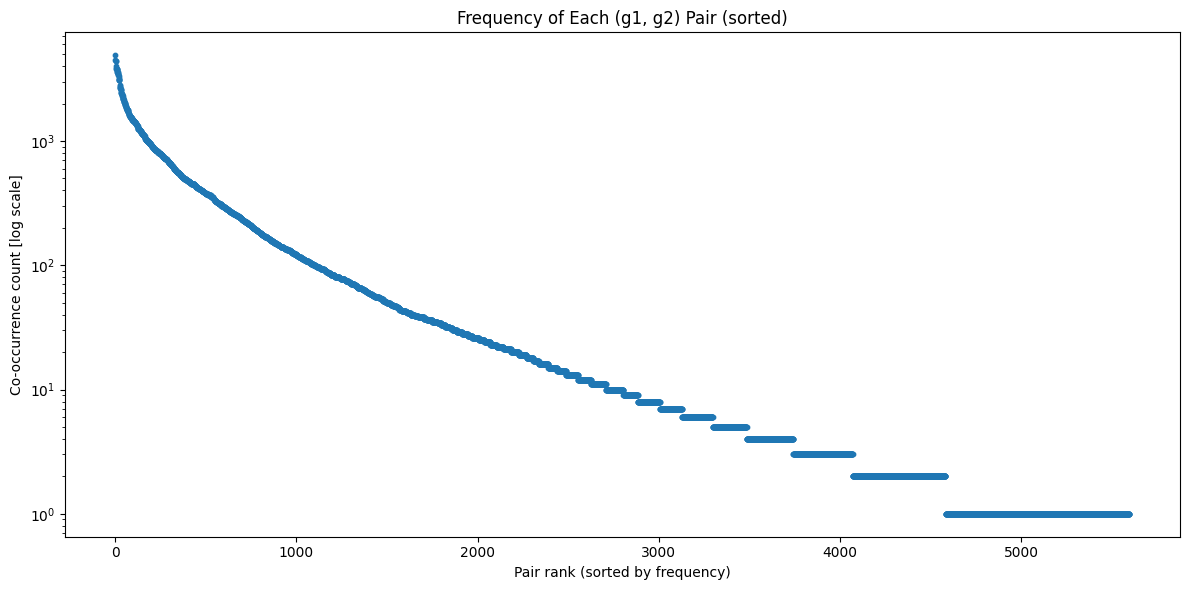

In [18]:
# === Load and extract the two ID columns fresh ===
tr_4000 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train4000.npy')
print("Train shape:", tr_4000.shape)

g1_vals = np.ravel(tr_4000[:, -2].astype(float))  # ensure 1-D
g2_vals = np.ravel(tr_4000[:, -1].astype(float))  # ensure 1-D

# Sanity check: must be the same length
if g1_vals.shape[0] != g2_vals.shape[0]:
    raise ValueError(f"Length mismatch: g1={g1_vals.shape[0]}, g2={g2_vals.shape[0]}. "
                     "Make sure you're pulling the last two columns from the same array.")

# Keep rows where both are finite
mask = np.isfinite(g1_vals) & np.isfinite(g2_vals)
g1c = np.rint(g1_vals[mask]).astype(int)
g2c = np.rint(g2_vals[mask]).astype(int)

# Build (g1,g2) pairs
pairs_clean = np.column_stack((g1c, g2c))

# Count co-occurrences
pair_counts = Counter(map(tuple, pairs_clean))

# Top-N print
TOP_N = 20
for (id1, id2), count in pair_counts.most_common(TOP_N):
    print(f"({id1}, {id2}) -> {count}")

# Heatmap on observed IDs
g1_ids = sorted({p[0] for p in pair_counts})
g2_ids = sorted({p[1] for p in pair_counts})
row_idx = {v: i for i, v in enumerate(g1_ids)}
col_idx = {v: j for j, v in enumerate(g2_ids)}

heatmap = np.zeros((len(g1_ids), len(g2_ids)), dtype=int)
for (id1, id2), c in pair_counts.items():
    heatmap[row_idx[id1], col_idx[id2]] = c

cmap = plt.cm.plasma_r.copy()
cmap.set_under('white')  # show zero-count cells as white
plt.figure(figsize=(9,7))
im = plt.imshow(
    heatmap, cmap=cmap, origin="lower",
    extent=[g2_ids[0]-0.5, g2_ids[-1]+0.5, g1_ids[0]-0.5, g1_ids[-1]+0.5],
    aspect='auto', vmin=1
)
plt.colorbar(im, label="Co-occurrence count")
plt.xlabel("Group 2 Mineral ID")
plt.ylabel("Group 1 Mineral ID")
plt.title("Co-occurrence Heatmap of Mineral IDs")
plt.grid(False)
plt.show()

# Scatter with labels for top 20
sorted_pairs = pair_counts.most_common()
freqs_sorted = [c for _, c in sorted_pairs]
plt.figure(figsize=(12,6))
plt.scatter(range(len(freqs_sorted)), freqs_sorted, s=10)
plt.yscale("log")
plt.xlabel("Pair rank (sorted by frequency)")
plt.ylabel("Co-occurrence count [log scale]")
plt.title("Frequency of Each (g1, g2) Pair (sorted)")
#for i, ((id1, id2), c) in enumerate(sorted_pairs[:TOP_N]):
    #plt.text(i, c, f"({id1},{id2})", fontsize=8, ha="center", va="bottom", rotation=45)
plt.tight_layout()
plt.show()


In [21]:
# Extract selected pixel indices across bands into a single matrix (no train/test split)

def extract_data_to_matrix(folder_path, selected_indices, output_matrix_path, n_bands=285):
    """
    Extracts data at selected indices for each TOAref_{w}.npy file and saves the matrix.
    Output shape: (len(selected_indices), n_bands)
    """
    selected_indices = np.asarray(selected_indices)
    if selected_indices.ndim != 1:
        raise ValueError("selected_indices must be a 1-D array of integer indices.")
    if selected_indices.size == 0:
        raise ValueError("selected_indices is empty.")

    # Load first band to infer dtype and pixel count
    first_path = os.path.join(folder_path, "TOAref_0.npy")
    first_band = np.load(first_path)
    flat_len = first_band.size
    dtype = first_band.dtype

    # Basic index validation
    if selected_indices.min() < 0 or selected_indices.max() >= flat_len:
        raise IndexError(
            f"Selected indices out of bounds (0..{flat_len-1}). "
            f"Min={selected_indices.min()}, Max={selected_indices.max()}"
        )

    # Preallocate output (rows = indices, cols = bands)
    out = np.empty((selected_indices.size, n_bands), dtype=dtype)

    # Fill each column from each band file
    for w in range(n_bands):
        file_path = os.path.join(folder_path, f"TOAref_{w}.npy")
        print(f"[{w+1:03d}/{n_bands}] Loading {file_path}")
        band = np.load(file_path).reshape(-1)  # flatten
        out[:, w] = band[selected_indices]

    # Save
    np.save(output_matrix_path, out)
    print(f"Saved matrix of shape {out.shape} to {output_matrix_path}")
    return out

if __name__ == "__main__":
    # === Configuration ===
    base_input_dir = '/Users/kmccoy/Documents/USC/Research/Dissertation/Data'
    folder_path = '/Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band'
    indices_path = f"{base_input_dir}/balanced_g1_g2_indices_MINperID_7500.npy"
    output_matrix_path = f"{base_input_dir}/TOApixel_balanced_W_train7500.npy"

    # === Load index pool ===
    selected_indices = np.load(indices_path)
    print(f"Loaded {len(selected_indices)} indices from {indices_path}")

    # === Extract and save ===
    extract_data_to_matrix(folder_path, selected_indices, output_matrix_path)


Loaded 1260203 indices from /Users/kmccoy/Documents/USC/Research/Dissertation/Data/balanced_g1_g2_indices_MINperID_7500.npy
[001/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_0.npy
[002/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_1.npy
[003/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_2.npy
[004/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_3.npy
[005/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_4.npy
[006/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_5.npy
[007/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_6.npy
[008/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_7.npy
[009/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_8.npy
[010/285] Loading /Volumes/LaCie/Dissertation/data/TOArefl_pca_output/band/TOAref_9.

In [22]:
#build train set of X for balanced dataset; X is gb1, bg2
#extract samples with no nan

new_sampled_indices=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data//balanced_g1_g2_indices_MINperID_7500.npy')
print(new_sampled_indices.shape)

# add Q variables
gb1 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepth.npy')
print(gb1.shape)
gb1flat_data = gb1.flatten()
gb1_retain=gb1flat_data[new_sampled_indices].reshape(-1,1)
print(gb1_retain.shape)
np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/gb1_pixel_balancedretain_7500.npy',gb1_retain)

gb2 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepth.npy')
print(gb2.shape)
gb2flat_data = gb2.flatten()
gb2_retain=gb2flat_data[new_sampled_indices].reshape(-1,1)
print(gb2_retain.shape)
np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/gb2_pixel_balancedretain_7500.npy',gb2_retain)

#combine with
W_retain=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_train7500.npy')
print(W_retain.shape)

gb1_retain=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/gb1_pixel_balancedretain_7500.npy')
gb1_retain=np.nan_to_num(gb1_retain)
print(gb1_retain.shape)

gb2_retain=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/gb2_pixel_balancedretain_7500.npy')
gb1_retain=np.nan_to_num(gb1_retain)
print(gb2_retain.shape)

retain_W_gb1_gb2_raw=np.hstack((W_retain,gb1_retain,gb2_retain))
print(retain_W_gb1_gb2_raw.shape)

np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_train7500.npy',retain_W_gb1_gb2_raw)

(1260203,)
(396, 1589760)
(1260203, 1)
(396, 1589760)
(1260203, 1)
(1260203, 285)
(1260203, 1)
(1260203, 1)
(1260203, 287)


In [23]:
#build train set of X for balanced dataset; X is gb1, gb2, gb1ID, gb2ID
#extract samples with no nan

#new_sampled_indices=np.load('/Volumes/big24Tb/USC/Research/Dissertation/Data/nonan_pixel_sampled_100K.npy')
new_sampled_indices=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/balanced_g1_g2_indices_MINperID_7500.npy')
print(new_sampled_indices.shape)

# add Q variables
gb1 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy')
print(gb1.shape)
gb1flat_data = gb1.flatten()
gb1_retain=gb1flat_data[new_sampled_indices].reshape(-1,1)
print(gb1_retain.shape)
np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/gb1ID_pixel_balancedretain_7500.npy',gb1_retain)

gb2 = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy')
print(gb2.shape)
gb2flat_data = gb2.flatten()
gb2_retain=gb2flat_data[new_sampled_indices].reshape(-1,1)
print(gb2_retain.shape)
np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/gb2ID_pixel_balancedretain_7500.npy',gb2_retain)

#combine with
W_retain=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_train7500.npy')
print(W_retain.shape)

gb1_retain=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/gb1ID_pixel_balancedretain_7500.npy')
gb1_retain=np.nan_to_num(gb1_retain)
print(gb1_retain.shape)

gb2_retain=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/gb2ID_pixel_balancedretain_7500.npy')
gb1_retain=np.nan_to_num(gb1_retain)
print(gb2_retain.shape)

retain_W_gb1_gb2_raw=np.hstack((W_retain,gb1_retain,gb2_retain))
print(retain_W_gb1_gb2_raw.shape)

np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy',retain_W_gb1_gb2_raw)

(1260203,)
(396, 1589760)
(1260203, 1)
(396, 1589760)
(1260203, 1)
(1260203, 287)
(1260203, 1)
(1260203, 1)
(1260203, 289)


Dataset shape: (766032, 289)
Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      1393
           2       0.90      0.88      0.89       497
           3       0.89      0.89      0.89        66
           4       0.63      0.57      0.60       681
           5       0.87      0.91      0.89       468
           6       0.76      0.73      0.74       504
           7       0.72      0.62      0.66       683
           8       0.71      0.66      0.68      1461
           9       0.90      0.95      0.92       485
          10       0.81      0.71      0.76       496
          11       0.75      0.90      0.82       521
          12       0.83      0.71      0.77         7
          13       0.72      0.76      0.74       500
          14       0.94      0.91      0.93       139
          15       0.79      0.71      0.75       504
          16       0.82      0.82      0.82       517
          17       0.5

/Users/kmccoy/diss_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kmccoy/diss_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kmccoy/diss_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kmccoy

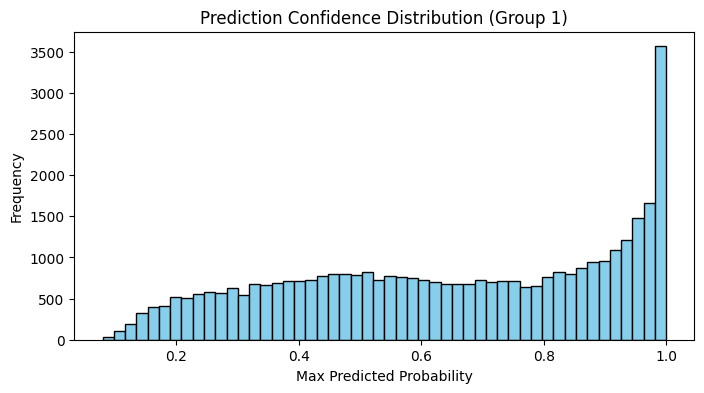

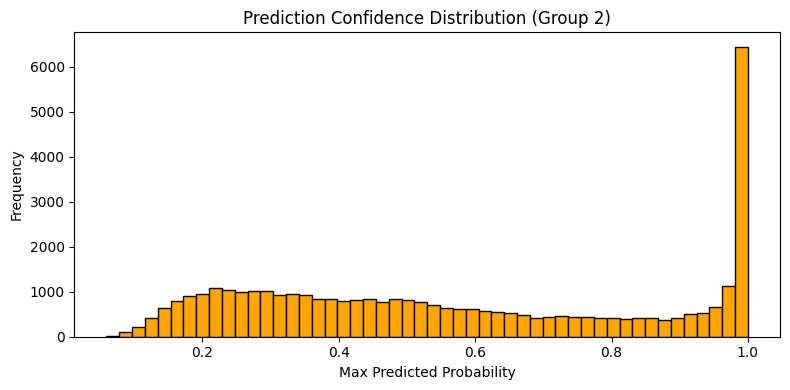

Low-confidence predictions (Group 1, prob < 0.7): 20451 out of 38302
Low-confidence predictions (Group 2, prob < 0.7): 24456 out of 38302


In [20]:
# Updated Mineral Prediction Script with Visualizations
# Handles categorical numerical labels from 0 to 294
# Adds probability output and six visualizations: confusion matrices, confidence histograms, and low-confidence samples for both groups

# Step 1: Load data
ID = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
print("Dataset shape:", ID.shape)

# Features and targets
W = ID[:, :285]
Q = ID[:, -2:].astype(int)  # Ensure labels are integers

# Step 2: Train-test split
W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 3: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 4: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Optional: Save predicted probabilities
np.save("pred_group1_10M.npy",pred_group1)
np.save("pred_group2_10M.npy",pred_group2)

np.save("proba_group1_10M.npy", proba_group1)
np.save("proba_group2_10M.npy", proba_group2)
np.save("max_probs_group1_10M.npy", max_probs_group1)
np.save("max_probs_group2_10M.npy", max_probs_group2)

# Step 5: Evaluate
print("Group 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1))

print("Group 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2))

# Confidence histogram for group1
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.show()

# Confidence histogram for group2
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Low-confidence predictions (threshold < 0.7) for group1
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
np.save("low_confidence_indices_group1_10M.npy", low_conf_indices1)

# Low-confidence predictions (threshold < 0.7) for group2
low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
np.save("low_confidence_indices_group2_10M.npy", low_conf_indices2)



Dataset shape: (1260203, 289)
Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      5868
           2       0.88      0.81      0.85       394
           3       0.91      0.96      0.94        78
           4       0.65      0.53      0.58      1547
           5       0.85      0.84      0.84       425
           6       0.73      0.66      0.70       426
           7       0.76      0.68      0.72      1299
           8       0.76      0.77      0.77      6650
           9       0.90      0.94      0.92       358
          10       0.82      0.64      0.72       461
          11       0.74      0.76      0.75       406
          12       0.60      0.75      0.67        12
          13       0.70      0.64      0.67       465
          14       0.95      0.85      0.90       145
          15       0.80      0.67      0.73       452
          16       0.79      0.79      0.79       392
          17       0.

/Users/kmccoy/diss_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kmccoy/diss_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kmccoy/diss_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kmccoy

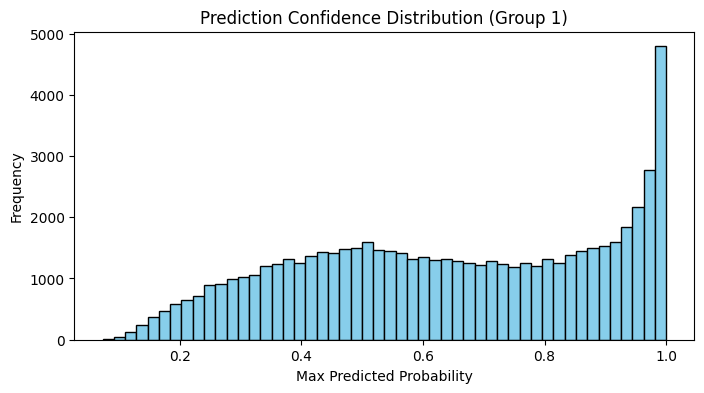

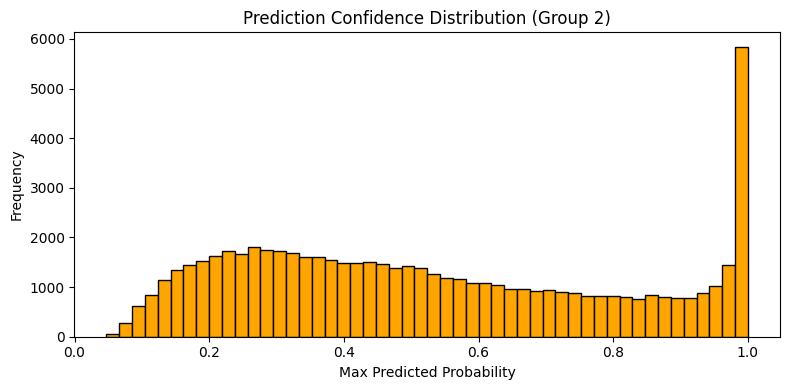

Low-confidence predictions (Group 1, prob < 0.7): 34928 out of 63011
Low-confidence predictions (Group 2, prob < 0.7): 44113 out of 63011


In [24]:
# Updated Mineral Prediction Script with Visualizations
# Handles categorical numerical labels from 0 to 294
# Adds probability output and six visualizations: confusion matrices, confidence histograms, and low-confidence samples for both groups

# Step 1: Load data
ID = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Dataset shape:", ID.shape)

# Features and targets
W = ID[:, :285]
Q = ID[:, -2:].astype(int)  # Ensure labels are integers

# Step 2: Train-test split
W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 3: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 4: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Optional: Save predicted probabilities
np.save("pred_group1_10M.npy",pred_group1)
np.save("pred_group2_10M.npy",pred_group2)

np.save("proba_group1_10M.npy", proba_group1)
np.save("proba_group2_10M.npy", proba_group2)
np.save("max_probs_group1_10M.npy", max_probs_group1)
np.save("max_probs_group2_10M.npy", max_probs_group2)

# Step 5: Evaluate
print("Group 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1))

print("Group 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2))

# Confidence histogram for group1
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.show()

# Confidence histogram for group2
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Low-confidence predictions (threshold < 0.7) for group1
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
np.save("low_confidence_indices_group1_10M.npy", low_conf_indices1)

# Low-confidence predictions (threshold < 0.7) for group2
low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
np.save("low_confidence_indices_group2_10M.npy", low_conf_indices2)



Train shape: (766032, 289)
Test shape: (2989, 289)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       102
           2       0.83      0.89      0.86        38
           3       0.86      1.00      0.92         6
           4       0.72      0.68      0.70        53
           5       0.74      0.86      0.80        37
           6       0.81      0.71      0.75        41
           7       0.77      0.59      0.67        46
           8       0.75      0.68      0.71       117
           9       0.88      1.00      0.94        36
          10       0.79      0.59      0.68        32
          11       0.69      0.87      0.77        31
          13       0.80      0.82      0.81        44
          14       0.86      0.92      0.89        13
          15       0.88      0.77      0.82        47
          16       0.83      0.88      0.85        40
          17       0.56      0.47      0.51        47

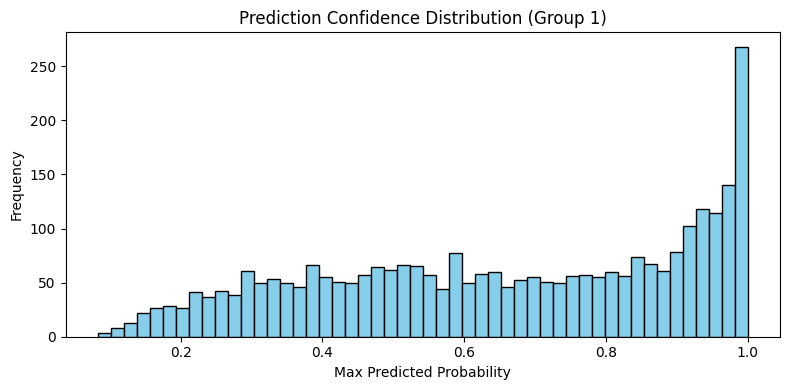

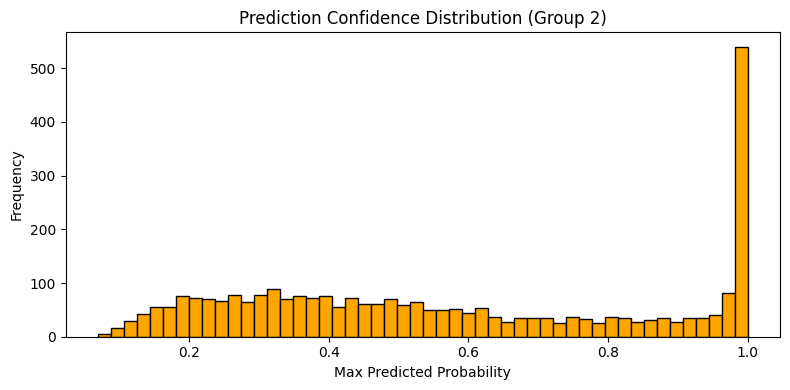

Low-confidence predictions (Group 1, prob < 0.7): 1561 out of 2989
Low-confidence predictions (Group 2, prob < 0.7): 1905 out of 2989


In [22]:
#use random forest classifier to predict mineral groups from balanced dataset (no knockoff features); 10k pixel samples
Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
print("Train shape:", Train.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2IDtest_10keach.npy')
print("Test shape:", Test.shape)

# Step 3: Reduce feature set
W_train = Train[:, :285]
Q_train = Train[:, -2:].astype(int)

W_test=Test[:, :285]
Q_test = Test[:, -2:].astype(int)

# Step 4: Train-test split
#W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
#np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
#np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)

Train shape: (1260203, 289)
Test shape: (2989, 289)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       102
           2       0.89      0.89      0.89        38
           3       1.00      1.00      1.00         6
           4       0.71      0.66      0.69        53
           5       0.84      0.84      0.84        37
           6       0.88      0.68      0.77        41
           7       0.76      0.67      0.71        46
           8       0.69      0.85      0.76       117
           9       0.92      1.00      0.96        36
          10       0.86      0.56      0.68        32
          11       0.90      0.87      0.89        31
          13       0.86      0.70      0.78        44
          14       0.93      1.00      0.96        13
          15       0.95      0.85      0.90        47
          16       0.89      0.82      0.86        40
          17       0.84      0.34      0.48        4

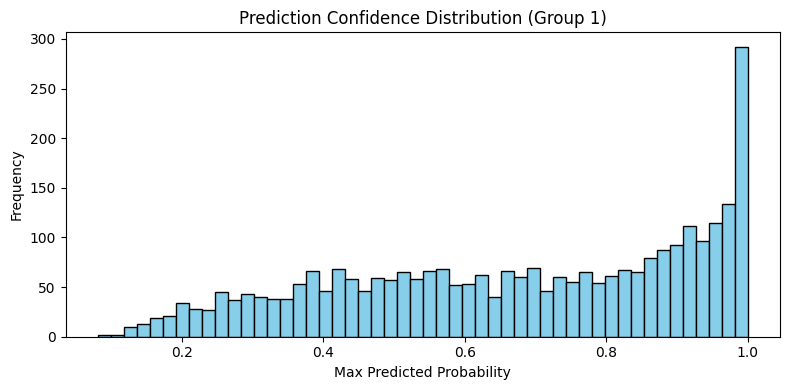

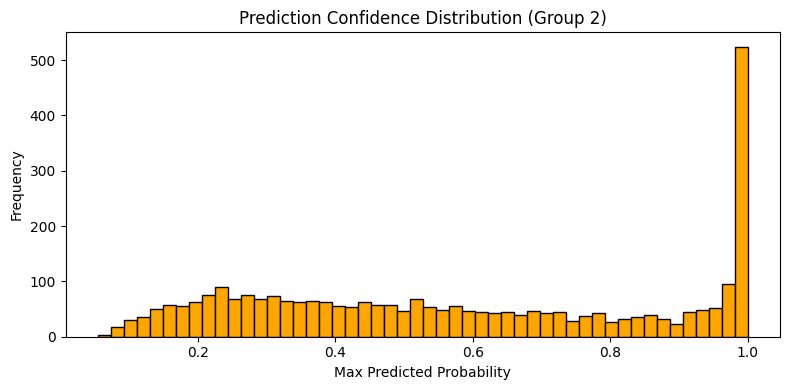

Low-confidence predictions (Group 1, prob < 0.7): 1485 out of 2989
Low-confidence predictions (Group 2, prob < 0.7): 1846 out of 2989


In [25]:
#use random forest classifier to predict mineral groups from balanced dataset (no knockoff features); 10k pixel samples
Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Train shape:", Train.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2IDtest_10keach.npy')
print("Test shape:", Test.shape)

# Step 3: Reduce feature set
W_train = Train[:, :285]
Q_train = Train[:, -2:].astype(int)

W_test=Test[:, :285]
Q_test = Test[:, -2:].astype(int)

# Step 4: Train-test split
#W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
#np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
#np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)

<div class="alert alert-block alert-success">
<span style="font-size: 15pt;"><b>use knockoff selections to predict group1,2 mineralID

Train shape: (766032, 289)
Test shape: (2989, 289)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       102
           2       0.82      0.87      0.85        38
           3       0.83      0.83      0.83         6
           4       0.65      0.64      0.65        53
           5       0.76      0.86      0.81        37
           6       0.86      0.73      0.79        41
           7       0.75      0.65      0.70        46
           8       0.73      0.72      0.72       117
           9       0.84      1.00      0.91        36
          10       0.81      0.66      0.72        32
          11       0.72      0.84      0.78        31
          13       0.74      0.80      0.77        44
          14       0.86      0.92      0.89        13
          15       0.88      0.77      0.82        47
          16       0.85      0.88      0.86        40
          17       0.61      0.47      0.53        47

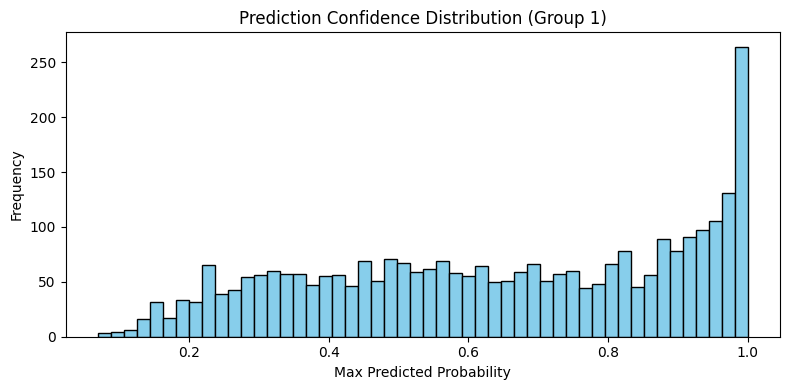

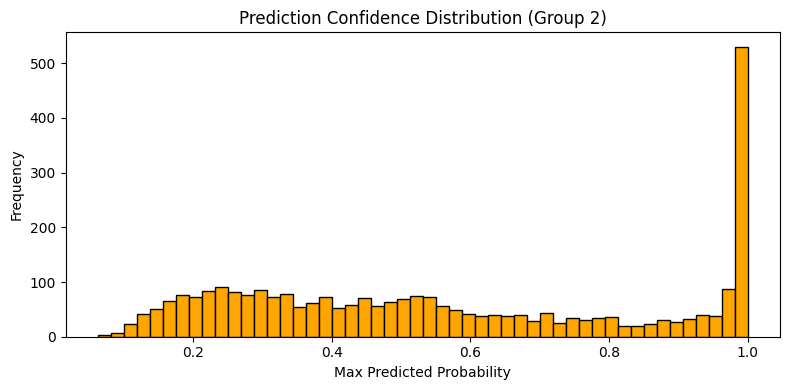

Low-confidence predictions (Group 1, prob < 0.7): 1618 out of 2989
Low-confidence predictions (Group 2, prob < 0.7): 1933 out of 2989


In [28]:
#Now classify using knockoffs from n=1000 pixel samples (to generate knockoffs, run knockoff filter script first)

# Load as strings → convert to numeric → drop NaN → convert to int
selected_1000 = pd.read_csv(
    "../Data/knockoffs/IPADselected_features_intersection_knockoff_plus1000q1.csv",
    header=None
).apply(pd.to_numeric, errors='coerce').dropna().values.flatten().astype(int)

# Convert to 0-based indexing for Python
selected_1000 = selected_1000 - 1

Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
print("Train shape:", Train.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2IDtest_10keach.npy')
print("Test shape:", Test.shape)

# Step 3: Reduce feature set
W_train = Train[:, selected_1000]
Q_train = Train[:, -2:].astype(int)

W_test=Test[:, selected_1000]
Q_test = Test[:, -2:].astype(int)

# Step 4: Train-test split
#W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
#np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
#np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)

Train shape: (766032, 289)
Test shape: (2989, 289)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       102
           2       0.89      0.87      0.88        38
           3       0.86      1.00      0.92         6
           4       0.72      0.62      0.67        53
           5       0.75      0.89      0.81        37
           6       0.85      0.71      0.77        41
           7       0.76      0.67      0.71        46
           8       0.75      0.73      0.74       117
           9       0.90      1.00      0.95        36
          10       0.74      0.62      0.68        32
          11       0.66      0.87      0.75        31
          13       0.84      0.84      0.84        44
          14       0.86      0.92      0.89        13
          15       0.93      0.81      0.86        47
          16       0.85      0.85      0.85        40
          17       0.57      0.36      0.44        47

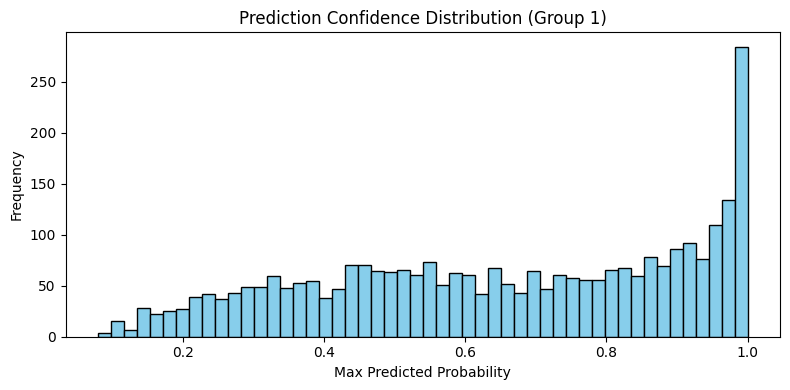

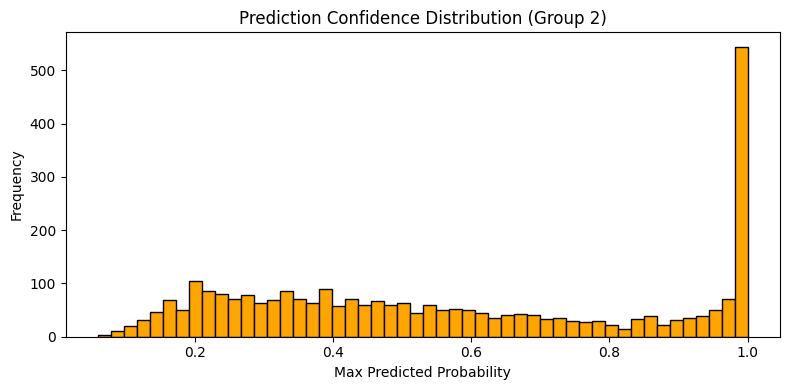

Low-confidence predictions (Group 1, prob < 0.7): 1570 out of 2989
Low-confidence predictions (Group 2, prob < 0.7): 1933 out of 2989


In [29]:
# Load as strings → convert to numeric → drop NaN → convert to int
selected_1000 = pd.read_csv(
    "../Data/knockoffs/IPADselected_features_intersection_knockoff_plus1000r1.csv",
    header=None
).apply(pd.to_numeric, errors='coerce').dropna().values.flatten().astype(int)

# Convert to 0-based indexing for Python
selected_1000 = selected_1000 - 1

Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
print("Train shape:", Train.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2IDtest_10keach.npy')
print("Test shape:", Test.shape)

# Step 3: Reduce feature set
W_train = Train[:, selected_1000]
Q_train = Train[:, -2:].astype(int)

W_test=Test[:, selected_1000]
Q_test = Test[:, -2:].astype(int)

# Step 4: Train-test split
#W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
#np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
#np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)

Train shape: (766032, 289)
Test shape: (2989, 289)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       102
           2       0.85      0.87      0.86        38
           3       0.86      1.00      0.92         6
           4       0.71      0.64      0.67        53
           5       0.76      0.86      0.81        37
           6       0.78      0.71      0.74        41
           7       0.74      0.67      0.70        46
           8       0.76      0.70      0.73       117
           9       0.88      1.00      0.94        36
          10       0.86      0.59      0.70        32
          11       0.70      0.84      0.76        31
          13       0.77      0.77      0.77        44
          14       0.86      0.92      0.89        13
          15       0.93      0.79      0.85        47
          16       0.85      0.88      0.86        40
          17       0.56      0.47      0.51        47

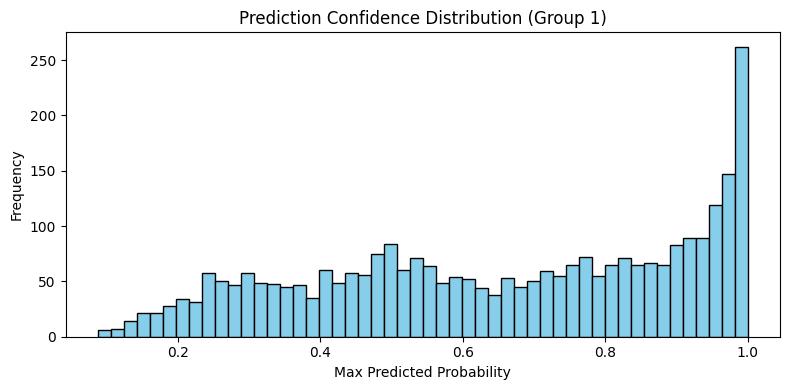

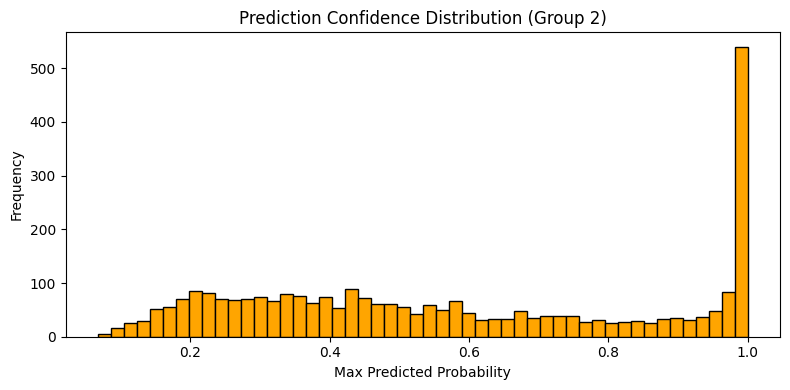

Low-confidence predictions (Group 1, prob < 0.7): 1542 out of 2989
Low-confidence predictions (Group 2, prob < 0.7): 1899 out of 2989


In [30]:
#Now classify using knockoffs from n=10000 pixel samples (to generate knockoffs, run knockoff filter script first)

# Load as strings → convert to numeric → drop NaN → convert to int
selected_1000 = pd.read_csv(
    "../Data/knockoffs/IPADselected_features_intersection_knockoff_plus10000q1.csv",
    header=None
).apply(pd.to_numeric, errors='coerce').dropna().values.flatten().astype(int)

# Convert to 0-based indexing for Python
selected_1000 = selected_1000 - 1

Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
print("Train shape:", Train.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2IDtest_10keach.npy')
print("Test shape:", Test.shape)

# Step 3: Reduce feature set
W_train = Train[:, selected_1000]
Q_train = Train[:, -2:].astype(int)

W_test=Test[:, selected_1000]
Q_test = Test[:, -2:].astype(int)

# Step 4: Train-test split
#W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
#np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
#np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)



Train shape: (766032, 289)
Test shape: (2989, 289)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       102
           2       0.85      0.87      0.86        38
           3       0.86      1.00      0.92         6
           4       0.66      0.62      0.64        53
           5       0.73      0.89      0.80        37
           6       0.83      0.71      0.76        41
           7       0.79      0.65      0.71        46
           8       0.75      0.68      0.72       117
           9       0.90      1.00      0.95        36
          10       0.86      0.59      0.70        32
          11       0.76      0.90      0.82        31
          13       0.80      0.82      0.81        44
          14       0.86      0.92      0.89        13
          15       0.88      0.81      0.84        47
          16       0.85      0.88      0.86        40
          17       0.56      0.40      0.47        47

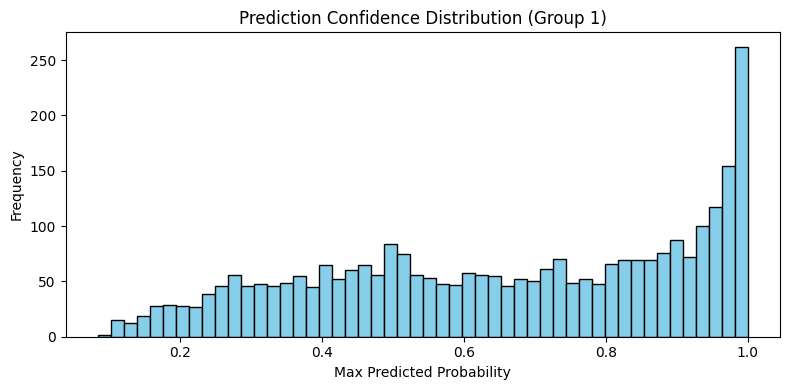

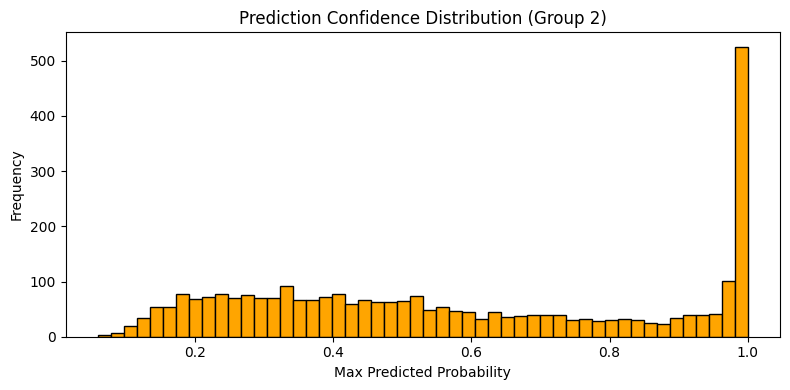

Low-confidence predictions (Group 1, prob < 0.7): 1550 out of 2989
Low-confidence predictions (Group 2, prob < 0.7): 1903 out of 2989


In [31]:
# Load as strings → convert to numeric → drop NaN → convert to int
selected_1000 = pd.read_csv(
    "../Data/knockoffs/IPADselected_features_intersection_knockoff_plus10000r1.csv",
    header=None
).apply(pd.to_numeric, errors='coerce').dropna().values.flatten().astype(int)

# Convert to 0-based indexing for Python
selected_1000 = selected_1000 - 1

Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
print("Train shape:", Train.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2IDtest_10keach.npy')
print("Test shape:", Test.shape)

# Step 3: Reduce feature set
W_train = Train[:, selected_1000]
Q_train = Train[:, -2:].astype(int)

W_test=Test[:, selected_1000]
Q_test = Test[:, -2:].astype(int)

# Step 4: Train-test split
#W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
#np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
#np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)

<div class="alert alert-block alert-success">
<span style="font-size: 15pt;"><b>use train set predict group1,2 mineralID for IMAGE 0

Train shape: (1260203, 289)
Test shape: (1589760, 287)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98   1426369
           4       0.19      0.01      0.02       488
           5       1.00      0.01      0.01       164
           6       0.00      0.00      0.00        57
           7       0.00      0.00      0.00        98
           8       0.14      0.03      0.05      1834
           9       0.06      0.69      0.11       108
          10       0.15      0.96      0.25      2795
          13       0.23      0.54      0.32      4210
          15       0.10      0.04      0.06       470
          16       0.08      0.12      0.10         8
          17       0.32      0.16      0.22        55
          18       0.00      0.00      0.00         2
          19       0.18      0.95      0.31       661
          20       0.44      0.06      0.11     12050
          21       0.33      0.01      0.02      

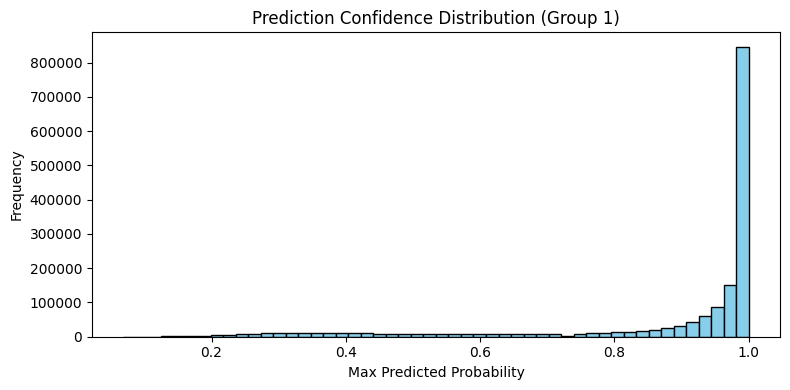

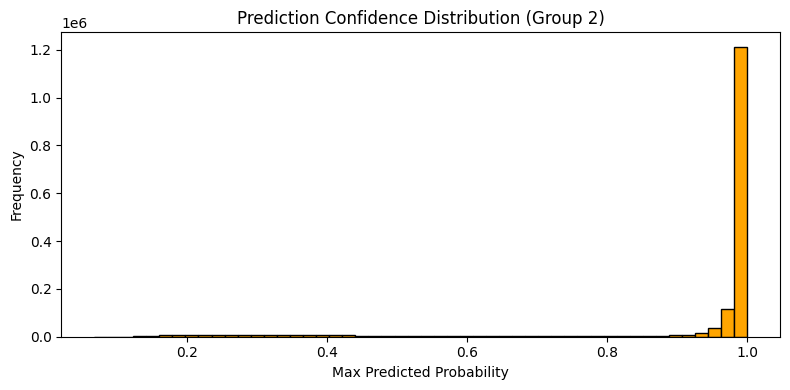

Low-confidence predictions (Group 1, prob < 0.7): 237379 out of 1589760
Low-confidence predictions (Group 2, prob < 0.7): 161956 out of 1589760


In [20]:
#use random forest classifier to predict mineral groups from balanced dataset (no knockoff features); 7.5k pixel samples
Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Train shape:", Train.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1ID_gb2ID_image0.npy')
print("Test shape:", Test.shape)

# Step 3: Reduce feature set
W_train = Train[:, :285]
Q_train = Train[:, -2:].astype(int)

W_test=Test[:, :285]
Q_test = Test[:, -2:].astype(int)

# Step 4: Train-test split
#W_train, W_test, Q_train, Q_test = train_test_split(W, Q, test_size=0.05, random_state=42)

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
#np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
#np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)

In [12]:
Train_all = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
#Train_all = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Train shape:", Train_all.shape)
Train_gb=Train_all[:,-4:-2]
Train_ID=Train_all[:,-2:].astype(int)

Train_new=np.hstack((Train_gb,Train_ID))
print(Train_new.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1ID_gb2ID_image0.npy')
print("Test shape:", Test.shape)
Test_ID=Test[:,-2:].astype(int)

gb1=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepthKNN.npy')
gb1_0=(gb1[0].T).reshape(-1,1)
print(gb1_0.shape)

gb2=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepthKNN.npy')
gb2_0=(gb2[0].T).reshape(-1,1)
print(gb2_0.shape)

Test_new=np.hstack((gb1_0,gb2_0,Test_ID))
print(Test_new.shape)

Train shape: (766032, 289)
(766032, 4)
Test shape: (1589760, 287)
(1589760, 1)
(1589760, 1)
(1589760, 4)


(766032, 2)
(766032, 2)
(1589760, 2)
(1589760, 2)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1426369
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00       488
           5       0.00      0.00      0.00       164
           6       0.00      0.00      0.00        57
           7       0.00      0.01      0.01        98
           8       0.01      0.14      0.02      1834
           9       0.03      0.36      0.05       108
          10       0.92      0.60      0.73      2795
          11       0.00      0.00      0.00         0
          13       0.01      0.00      0.00      4210
          14       0.00      0.00      0.00         0
          15       0.04      0.14      0.06       470
          16       0.00      0.00      0.00         8
          17       0.00      0.40      0.01        55


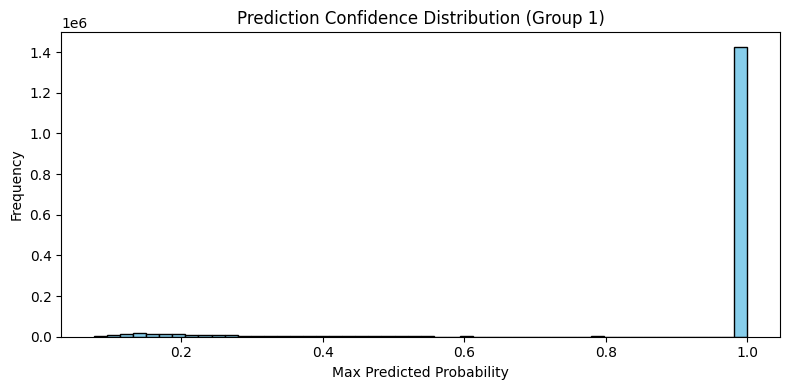

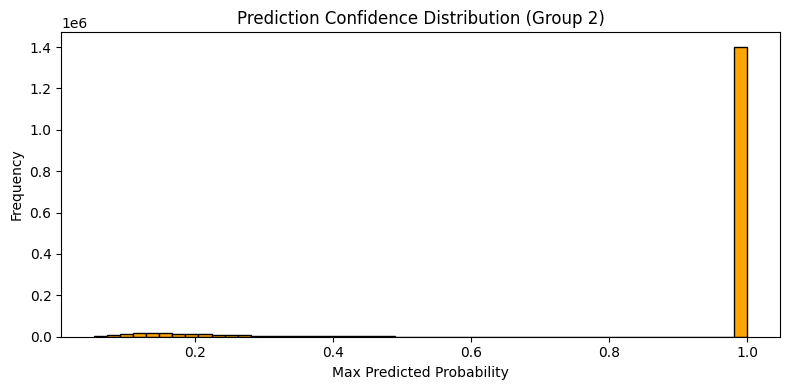

Low-confidence predictions (Group 1, prob < 0.7): 159925 out of 1589760
Low-confidence predictions (Group 2, prob < 0.7): 186746 out of 1589760


In [13]:

# Step 3: Reduce feature set
W_train = Train_new[:, :2]
Q_train = Train_new[:, -2:].astype(int)
print(W_train.shape)
print(Q_train.shape)

W_test = Test_new[:, :2]
Q_test = Test_new[:, -2:].astype(int)
print(W_test.shape)
print(Q_test.shape) 

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(
    n_estimators=50, max_depth=25, n_jobs=-1, random_state=0
)
clf_group2 = RandomForestClassifier(
    n_estimators=50, max_depth=25, n_jobs=-1, random_state=0
)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

# --- NEW: Enforce deterministic zero rule (column-wise) ---
# If col0 in W_test == 0 → force Group1 prediction = 0
# If col1 in W_test == 0 → force Group2 prediction = 0

mask_col0 = (W_test[:, 0] == 0)
mask_col1 = (W_test[:, 1] == 0)

# Force predictions
pred_group1[mask_col0] = 0
pred_group2[mask_col1] = 0

# Force probabilities
if np.any(mask_col0):
    k = np.sum(mask_col0)
    if proba_group1.shape[1] == 2:
        proba_group1[mask_col0] = np.tile([1.0, 0.0], (k, 1))
    else:  # degenerate case: only one class seen in training
        proba_group1[mask_col0] = 1.0

if np.any(mask_col1):
    k = np.sum(mask_col1)
    if proba_group2.shape[1] == 2:
        proba_group2[mask_col1] = np.tile([1.0, 0.0], (k, 1))
    else:
        proba_group2[mask_col1] = 1.0

# recompute max probs
max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 1, prob < 0.7): "
    f"{len(low_conf_indices1)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 2, prob < 0.7): "
    f"{len(low_conf_indices2)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)


In [14]:
Train_all = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
#Train_all = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Train shape:", Train_all.shape)
Train_gb=Train_all[:,-4:-2]
Train_ID=Train_all[:,-2:].astype(int)

Train_new=np.hstack((Train_gb,Train_ID))
print(Train_new.shape)

gb1=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepthKNN.npy')
gb1_0=(gb1[0].T).ravel()
print(gb1_0.shape)

gb2=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepthKNN.npy')
gb2_0=(gb2[0].T).ravel()
print(gb2_0.shape)

predicted=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/exp_Q_allfeat_image0.npy')
gb1_0pred=predicted[:,0].ravel()
gb2_0pred=predicted[:,1].ravel()

gb1_0pred[gb1_0 == 0] = 0
gb1_0pred=gb1_0pred.reshape(-1,1)

gb2_0pred[gb2_0 == 0] = 0
gb2_0pred=gb2_0pred.reshape(-1,1)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1ID_gb2ID_image0.npy')
print("Test shape:", Test.shape)
Test_ID=Test[:,-2:].astype(int)

Test_new=np.hstack((gb1_0pred,gb2_0pred,Test_ID))
print(Test_new.shape)

Train shape: (766032, 289)
(766032, 4)
(1589760,)
(1589760,)
Test shape: (1589760, 287)
(1589760, 4)


(766032, 2)
(766032, 2)
(1589760, 2)
(1589760, 2)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1426369
           2       0.00      0.00      0.00         0
           4       0.00      0.00      0.00       488
           5       0.00      0.00      0.00       164
           6       0.00      0.00      0.00        57
           7       0.00      0.00      0.00        98
           8       0.06      0.12      0.08      1834
           9       0.01      0.19      0.02       108
          10       0.93      0.16      0.27      2795
          11       0.00      0.00      0.00         0
          13       0.00      0.00      0.00      4210
          15       0.11      0.72      0.20       470
          16       0.00      0.00      0.00         8
          17       0.00      0.29      0.00        55
          18       0.00      0.00      0.00         2
          19       0.03      0.02      0.02       661


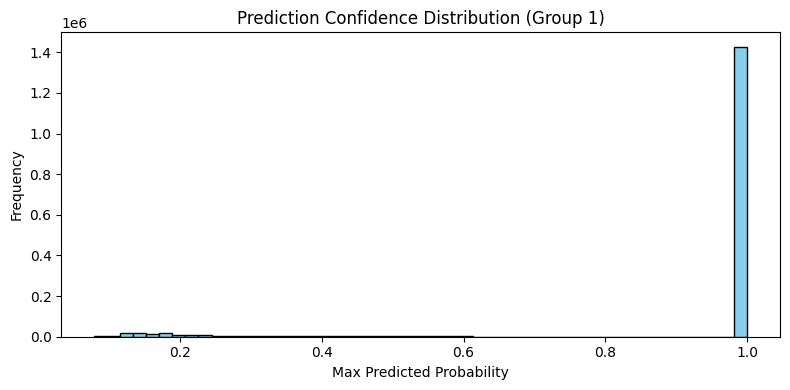

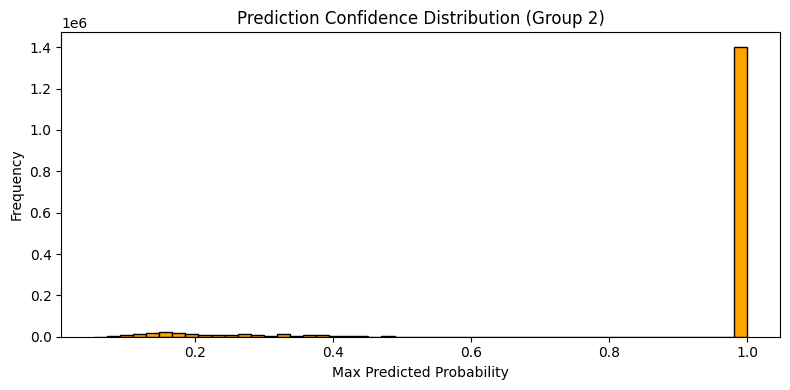

Low-confidence predictions (Group 1, prob < 0.7): 159771 out of 1589760
Low-confidence predictions (Group 2, prob < 0.7): 187421 out of 1589760


In [15]:

# Step 3: Reduce feature set
W_train = Train_new[:, :2]
Q_train = Train_new[:, -2:].astype(int)
print(W_train.shape)
print(Q_train.shape)

W_test = Test_new[:, :2]
Q_test = Test_new[:, -2:].astype(int)
print(W_test.shape)
print(Q_test.shape) 

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(
    n_estimators=50, max_depth=25, n_jobs=-1, random_state=0
)
clf_group2 = RandomForestClassifier(
    n_estimators=50, max_depth=25, n_jobs=-1, random_state=0
)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

# --- NEW: Enforce deterministic zero rule (column-wise) ---
# If col0 in W_test == 0 → force Group1 prediction = 0
# If col1 in W_test == 0 → force Group2 prediction = 0

mask_col0 = (W_test[:, 0] == 0)
mask_col1 = (W_test[:, 1] == 0)

# Force predictions
pred_group1[mask_col0] = 0
pred_group2[mask_col1] = 0

# Force probabilities
if np.any(mask_col0):
    k = np.sum(mask_col0)
    if proba_group1.shape[1] == 2:
        proba_group1[mask_col0] = np.tile([1.0, 0.0], (k, 1))
    else:  # degenerate case: only one class seen in training
        proba_group1[mask_col0] = 1.0

if np.any(mask_col1):
    k = np.sum(mask_col1)
    if proba_group2.shape[1] == 2:
        proba_group2[mask_col1] = np.tile([1.0, 0.0], (k, 1))
    else:
        proba_group2[mask_col1] = 1.0

# recompute max probs
max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 1, prob < 0.7): "
    f"{len(low_conf_indices1)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 2, prob < 0.7): "
    f"{len(low_conf_indices2)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)


In [ ]:
#use random forest classifier to predict mineral groups from balanced dataset (no knockoff features); 7.5k pixel samples
Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Train shape:", Train.shape)

Test=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1ID_gb2ID_image0.npy')
print("Test shape:", Test.shape)

# Step 3: Reduce feature set
W_train = Train[:, :285]
Q_train = Train[:, -2:].astype(int)
X=np.hstack((W_train,Q_train))
print(X.shape)
np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1ID_gb2ID_train7500.npy',X)

W_test=Test[:, :285]
Q_test = Test[:, -2:].astype(int)

Q = np.arange(285, 287)
print(Q.shape)

cond_cols = np.arange(0, 285)
print(cond_cols.shape)

wfile = Test[:, :285]
print(wfile.shape)

#exp_Q = []
#for i in range(wfile.shape[0]):
#    expn, var = plom1._conditional_expectation(X, Q, cond_cols, wfile[i])
#    exp_Q.append(expn)
#exp_Q = np.array(exp_Q)
#print(exp_Q.shape)

#np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApredict_pixelbalanced_766Knew.npy',exp_Q)


Train shape: (1260203, 289)
Test shape: (1589760, 287)
(1260203, 287)
(2,)
(285,)
(1589760, 285)


In [ ]:
M=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/exp_Q_allfeat_gID_img0.npy')
print(M[:5, :])
# Round half up to nearest integer (works for negatives too)
rounded = np.floor(M + 0.5)
Img4ID_pred = rounded.astype(int)
print(Img4ID_pred[:5, :])

Img4ID_actual=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1_gb2_gb1ID_gb2ID_image0.npy')
Img4ID_actual=Img4ID_actual[:,-2:].astype(int)
print(Img4ID_actual[:5, :])


[[ 53.37601848 191.66636341]
 [ 58.19047379 191.42365204]
 [ 57.51011578 191.45753858]
 [ 50.88811252 191.63262513]
 [ 51.48174426 191.65208783]]
[[ 53 192]
 [ 58 191]
 [ 58 191]
 [ 51 192]
 [ 51 192]]
[[ 47 192]
 [ 47 191]
 [ 47 191]
 [ 47 191]
 [ 47 191]]


Column 0 — Confusion Matrix (counts):
Pred    0   4   8   13  16  18  19  20  21  22  ...  67  68  69  70  71  72  \
Actual                                          ...                           
0        0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
4        0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
8        4   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
13       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
16       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
...     ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...  ..  ..  ..  ..  ..  ..   
72       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
73       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
74       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
75       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
80       3   0

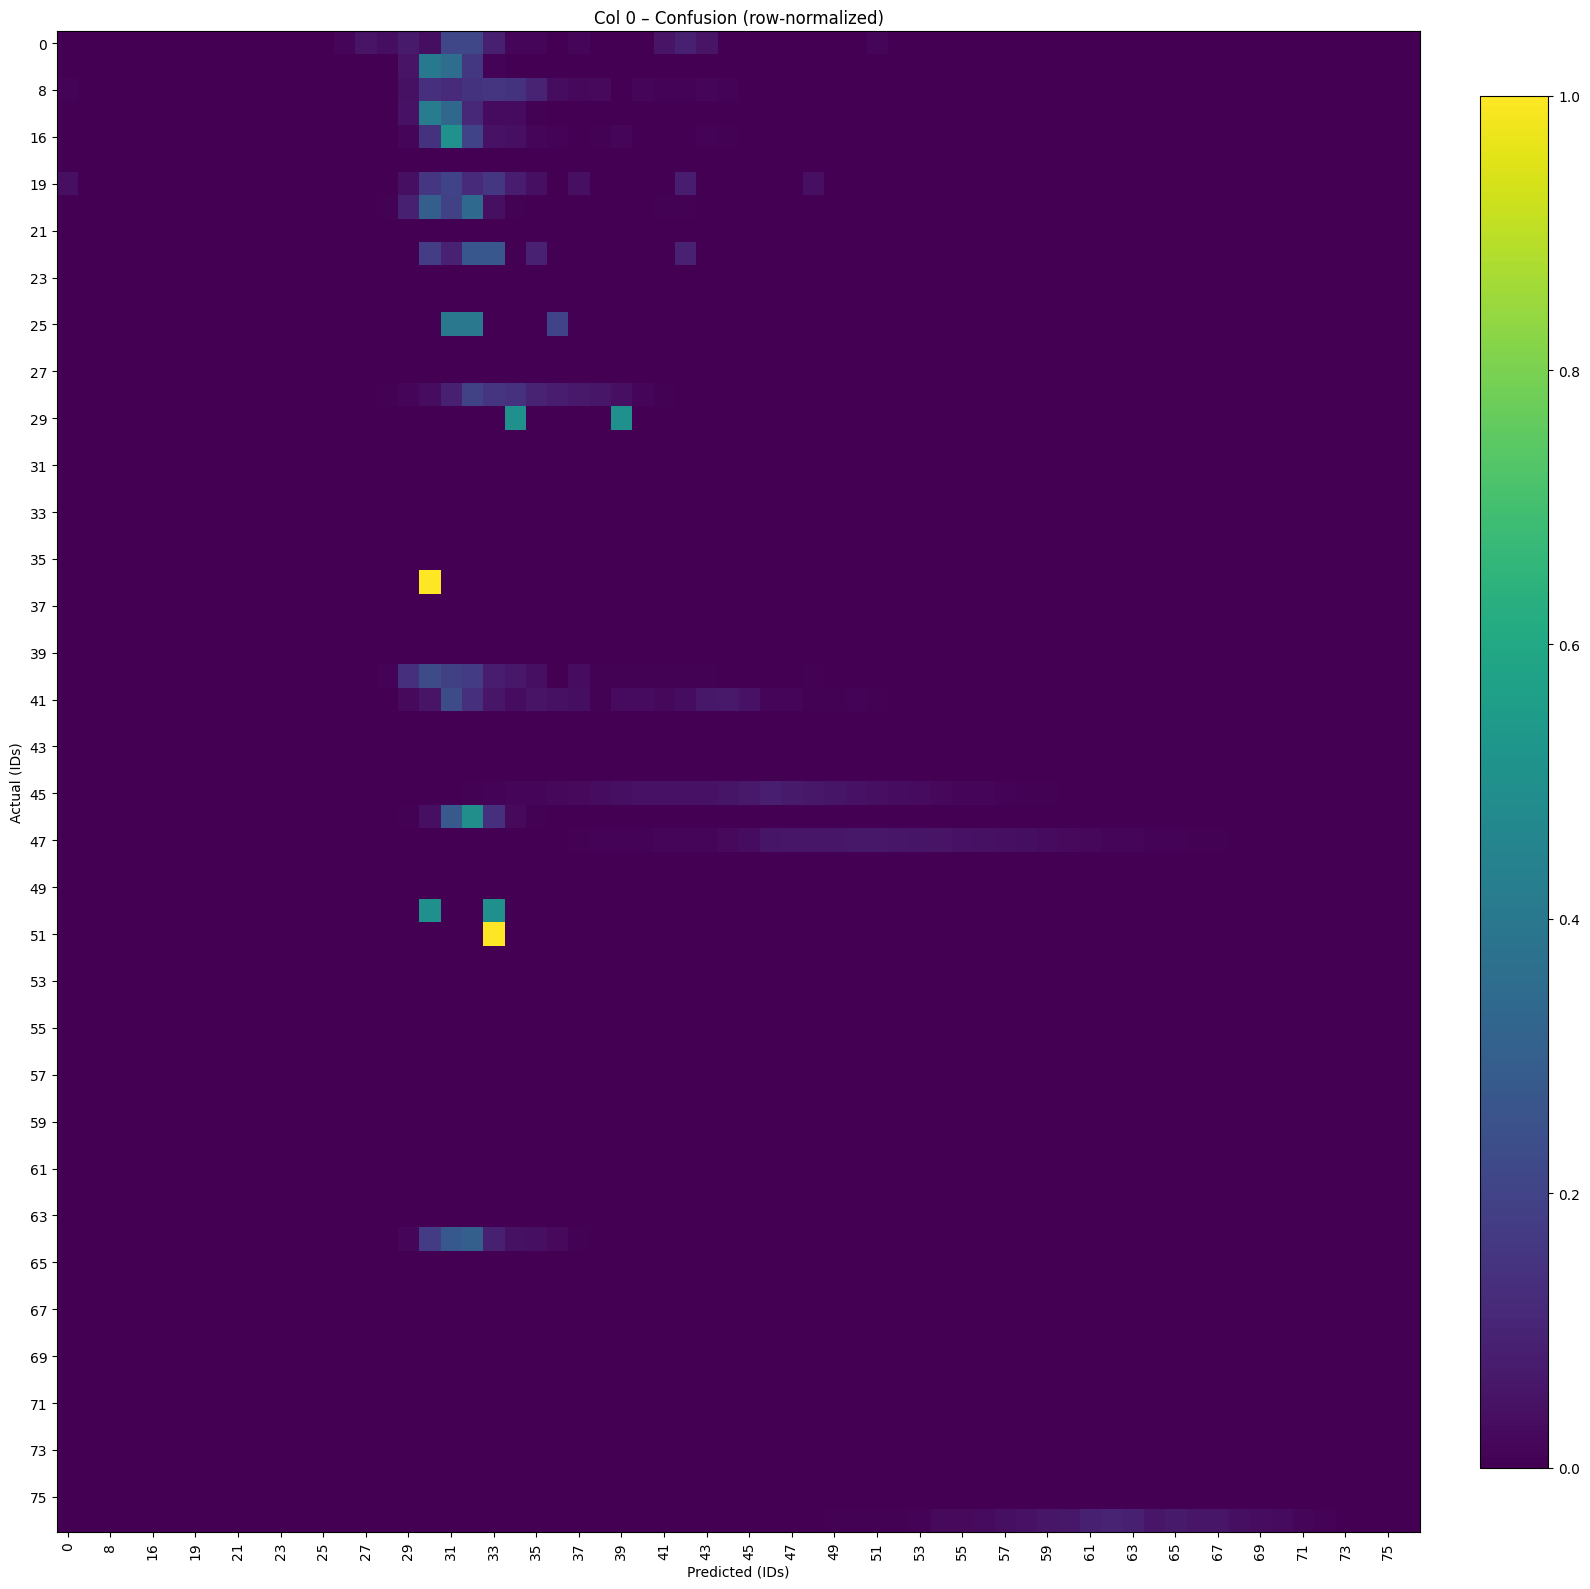

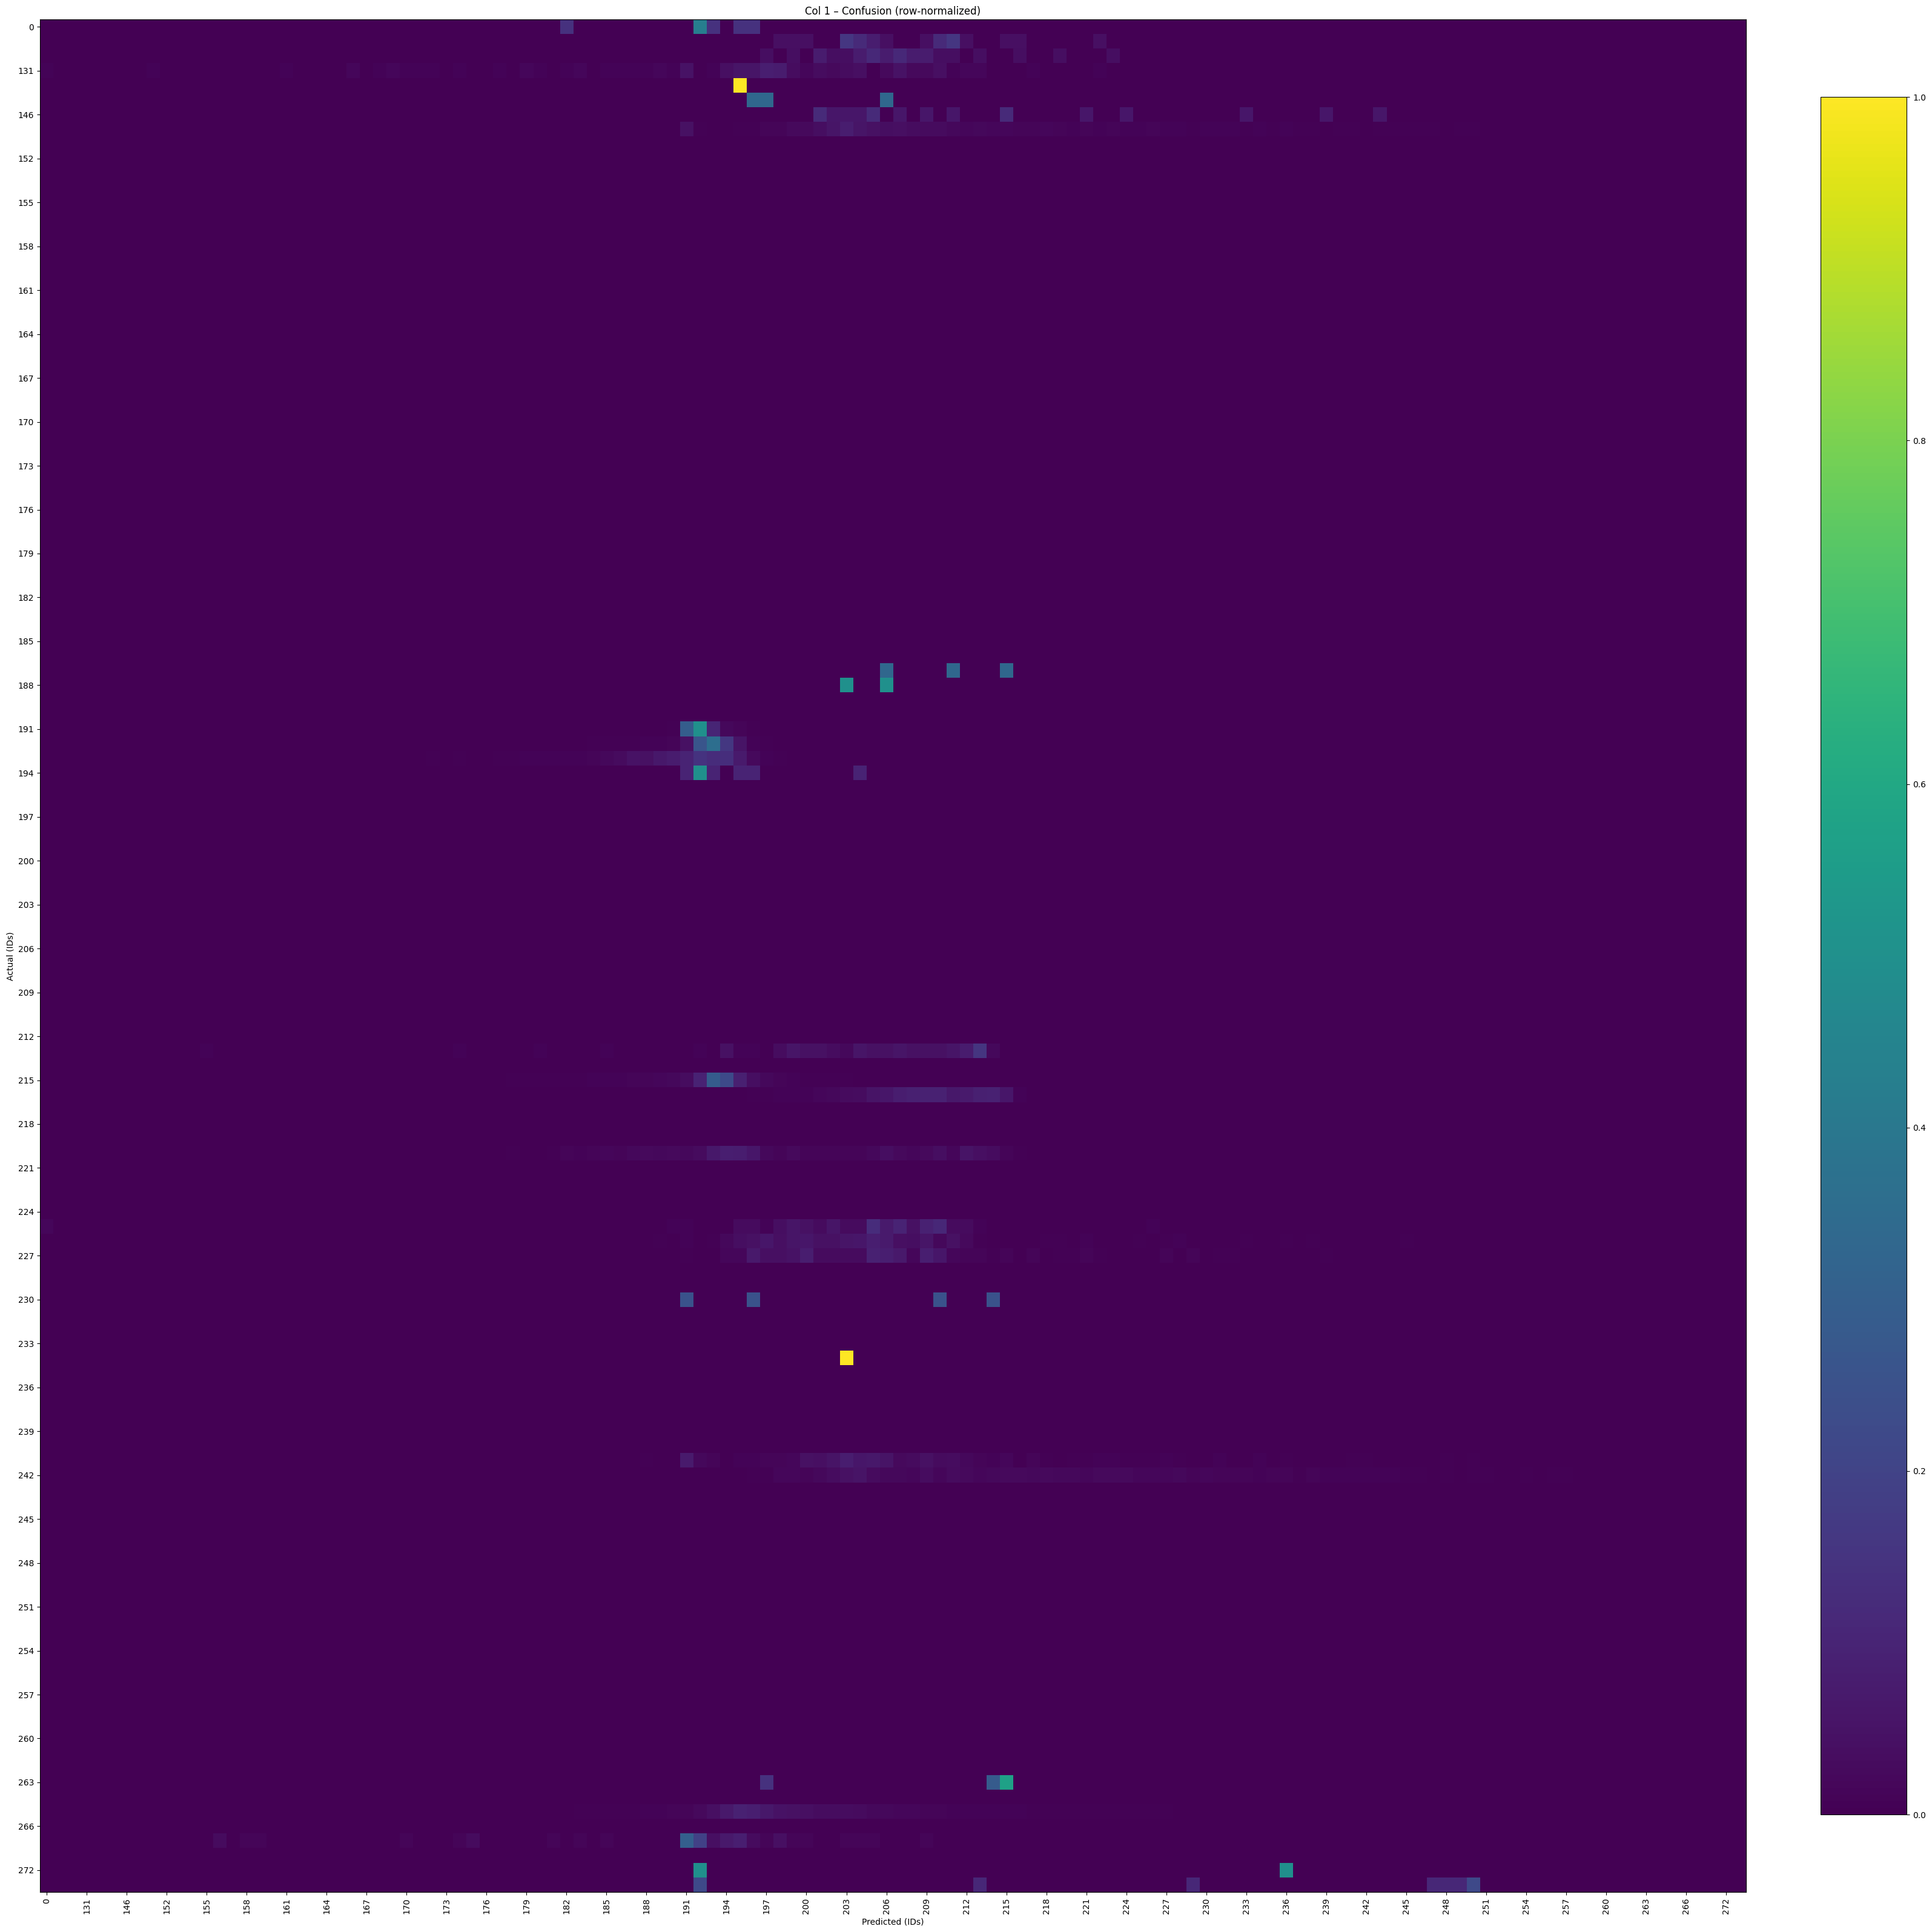

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# --- Load your arrays ---
# Preds (float, may contain NaNs); do half-up rounding but keep float so NaNs survive
P = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/exp_Q_allfeat_gID_img0.npy')
P = np.floor(P + 0.5)  # round half up

# Actuals (float or int; may contain NaNs)
A = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1_gb2_gb1ID_gb2ID_image0.npy') 
A=A[:,-2:].astype(int)

# --- Ensure we have a 2D shape with last dim = features ---
# (e.g., if shape is (H, W, 2) or (N, 2), this reshapes to (?, 2))
P2 = P.reshape(-1, P.shape[-1])
A2 = A.reshape(-1, A.shape[-1])

def confusion_for_column(A2, P2, col):
    # Take column
    a = A2[:, col]
    p = P2[:, col]

    # Mask out NaNs in either
    mask = np.isfinite(a) & np.isfinite(p)
    a = a[mask].astype(int, copy=False)
    p = p[mask].astype(int, copy=False)

    # Labels present in either
    labels = np.unique(np.concatenate([a, p]))

    # Confusion matrix (counts)
    cm = confusion_matrix(a, p, labels=labels
    cm_df = pd.DataFrame(cm, index=pd.Index(labels, name="Actual"),
                            columns=pd.Index(labels, name="Pred"))

    # Row-normalized
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums != 0)
    cm_norm_df = pd.DataFrame(cm_norm, index=pd.Index(labels, name="Actual"),
                                columns=pd.Index(labels, name="Pred"))

    acc = (a == p).mean() if a.size else float('nan')
    return cm_df, cm_norm_df, acc, labels

# --- Column 0 ---
cm0, cm0_norm, acc0, labels0 = confusion_for_column(A2, P2, 0)
print("Column 0 — Confusion Matrix (counts):")
print(cm0)
print("\nColumn 0 — Row-normalized:")
print(cm0_norm.round(3))
print(f"\nColumn 0 — Accuracy: {acc0:.4f}\n")

# --- Column 1 ---
cm1, cm1_norm, acc1, labels1 = confusion_for_column(A2, P2, 1)
print("Column 1 — Confusion Matrix (counts):")
print(cm1)
print("\nColumn 1 — Row-normalized:")
print(cm1_norm.round(3))
print(f"\nColumn 1 — Accuracy: {acc1:.4f}")


def show_heatmap_from_df(df, title, annotate_if_small=True, max_ticks=50):
    """
    df: pandas DataFrame whose index = Actual IDs, columns = Predicted IDs
    """
    vals = df.values
    rows, cols = df.index, df.columns

    # Figure size scales with number of labels
    fig_w = max(7, 0.25 * len(cols))
    fig_h = max(6, 0.25 * len(rows))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(vals, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Predicted (IDs)')
    ax.set_ylabel('Actual (IDs)')

    # Choose ticks (sample if too many)
    def sampled_ticks(n, labels):
        if n <= max_ticks:
            idx = np.arange(n)
        else:
            step = int(np.ceil(n / max_ticks))
            idx = np.arange(0, n, step)
        return idx, [labels[i] for i in idx]

    xticks, xticklabels = sampled_ticks(len(cols), list(cols))
    yticks, yticklabels = sampled_ticks(len(rows), list(rows))

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Annotate cells if small enough
    if annotate_if_small and df.shape[0] <= 20 and df.shape[1] <= 20:
        is_float = np.issubdtype(vals.dtype, np.floating)
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                text = f"{vals[i, j]:.2f}" if is_float else str(int(vals[i, j]))
                ax.text(j, i, text, ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

# Row-normalized
show_heatmap_from_df(cm0_norm, "Col 0 – Confusion (row-normalized)")
show_heatmap_from_df(cm1_norm, "Col 1 – Confusion (row-normalized)")

<div class="alert alert-block alert-success">
<span style="font-size: 15pt;"><b>use train set predict group1,2 mineralID for IMAGE 4

In [21]:
#formulate an image pixel dataset with TOA reflectance, band depth features, and mineral IDs for image 4
Image4=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOAref_image4_1589760x285.npy')
print("Image shape:", Image4.shape)

gb1=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepthKNN.npy')
#gb1=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepth.npy')
gb1_4=(gb1[4].T).reshape(-1,1)
print(gb1_4.shape)

gb2=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepthKNN.npy')
#gb2=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepth.npy')
gb2_4=(gb2[4].T).reshape(-1,1)
print(gb2_4.shape)

gb1ID=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy')
gb1ID_4=(gb1ID[4].T).reshape(-1,1)
print(gb1ID_4.shape)

gb2ID=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy')
gb2ID_4=(gb2ID[4].T).reshape(-1,1)
print(gb2ID_4.shape)

Test_new4=np.hstack((Image4,gb1_4,gb2_4,gb1ID_4,gb2ID_4))
print(Test_new4.shape)

np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1_gb2_gb1ID_gb2ID_image4.npy',Test_new4)

Image shape: (1589760, 285)
(1589760, 1)
(1589760, 1)
(1589760, 1)
(1589760, 1)
(1589760, 289)


Train shape: (1260203, 289)
Test shape: (1589760, 289)
W_train: (1260203, 285) Q_train: (1260203, 2)
W_test: (1589760, 285) Q_test: (1589760, 2)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.11      0.02      0.03        56
           4       0.38      0.26      0.31      1852
           7       0.00      0.00      0.00         0
           8       0.71      0.03      0.05       358
          13       0.15      0.05      0.07      1418
          16       0.07      0.48      0.12       255
          19       0.13      0.32      0.19        25
          20       0.14      0.02      0.04       146
          22       0.00      0.00      0.00        11
          25       0.00      0.00      0.00         5
          28       0.88      0.94      0.91    429664
          29       0.07      1.00      0.13         2
          36       0.00      0.00      0.00         1
          40       0.00      0.00      0.00       173
          41 

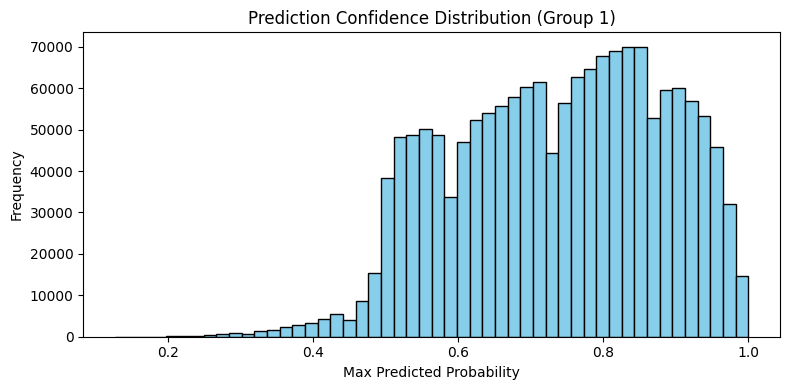

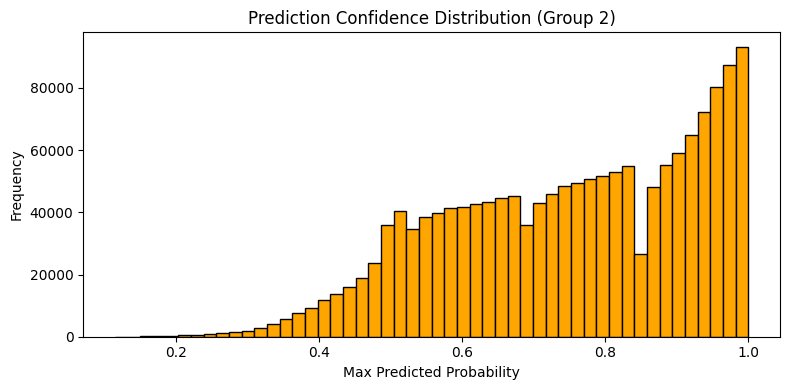

Low-confidence predictions (Group 1, prob < 0.7): 633359 out of 1589760
Low-confidence predictions (Group 2, prob < 0.7): 610943 out of 1589760


In [25]:

# Step 1: Load data
Train = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Train shape:", Train.shape)

Test = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1_gb2_gb1ID_gb2ID_image4.npy')
print("Test shape:", Test.shape)

# Step 3: Split into features (W) and labels (Q)
W_train = Train[:, :285]
Q_train = Train[:, -2:].astype(int)

W_test = Test[:, :285]
Q_test = Test[:, -2:].astype(int)

print("W_train:", W_train.shape, "Q_train:", Q_train.shape)
print("W_test:", W_test.shape, "Q_test:", Q_test.shape)

# Step 5: Train classifiers
clf_group1 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)
clf_group2 = RandomForestClassifier(n_estimators=50, max_depth=25, n_jobs=-1, random_state=0)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

# --- NEW: Enforce deterministic zero rule ---
# If all 285 features of W_test row == 0 → force both predictions = 0
zero_mask = np.all(W_test == 0, axis=1)

pred_group1[zero_mask] = 0
pred_group2[zero_mask] = 0

if np.any(zero_mask):
    k = np.sum(zero_mask)
    if proba_group1.shape[1] == 2:
        proba_group1[zero_mask] = np.tile([1.0, 0.0], (k, 1))
    else:  # degenerate case: only one class seen
        proba_group1[zero_mask] = 1.0

    if proba_group2.shape[1] == 2:
        proba_group2[zero_mask] = np.tile([1.0, 0.0], (k, 1))
    else:
        proba_group2[zero_mask] = 1.0

# recompute max probs
max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(f"Low-confidence predictions (Group 1, prob < 0.7): {len(low_conf_indices1)} out of {len(W_test)}")
# np.save("low_confidence_indices_group1.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(f"Low-confidence predictions (Group 2, prob < 0.7): {len(low_conf_indices2)} out of {len(W_test)}")
# np.save("low_confidence_indices_group2.npy", low_conf_indices2)


In [28]:
#Train_all = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_10keach.npy')
Train_all = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Train shape:", Train_all.shape)
Train_gb=Train_all[:,-4:-2]
Train_ID=Train_all[:,-2:].astype(int)

Train_new=np.hstack((Train_gb,Train_ID))
print(Train_new.shape)

gb1=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepthKNN.npy')
#gb1=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepth.npy')
gb1_4=(gb1[4].T).reshape(-1,1)
print(gb1_4.shape)

gb2=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepthKNN.npy')
#gb2=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepth.npy')
gb2_4=(gb2[4].T).reshape(-1,1)
print(gb2_4.shape)

gb1ID=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy')
gb1ID_4=(gb1ID[4].T).reshape(-1,1)
print(gb1ID_4.shape)

gb2ID=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy')
gb2ID_4=(gb2ID[4].T).reshape(-1,1)
print(gb2ID_4.shape)

Test_new=np.hstack((gb1_4,gb2_4,gb1ID_4,gb2ID_4))
print(Test_new.shape)

Train shape: (1260203, 289)
(1260203, 4)
(1589760, 1)
(1589760, 1)
(1589760, 1)
(1589760, 1)
(1589760, 4)


(1260203, 2)
(1260203, 2)
(1589760, 2)
(1589760, 2)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        56
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00      1852
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.11      0.00       358
          10       0.00      0.00      0.00         0
          13       0.00      0.00      0.00      1418
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0
          16       0.00      0.00      0.00       255
          17       0.00      0.00      0.00         0
          19       0.00      0.00      0.00        25
          20       0.03      0.06      0.04       14

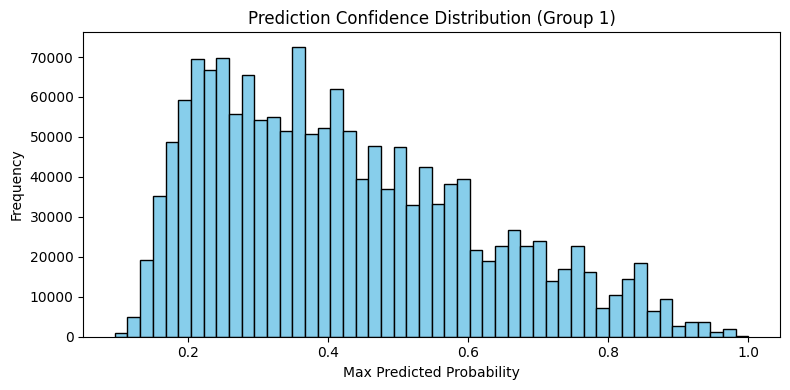

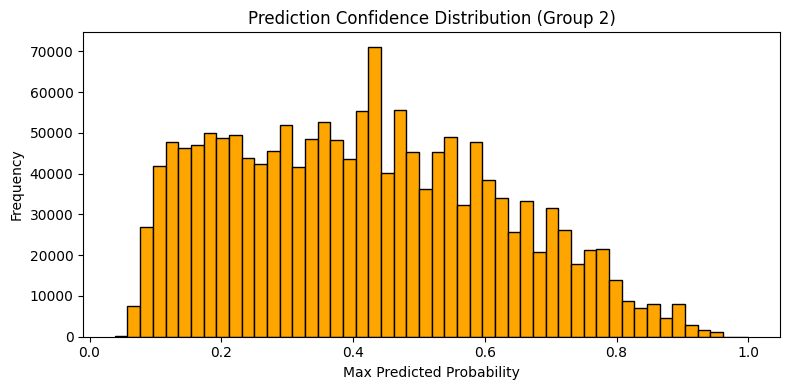

Low-confidence predictions (Group 1, prob < 0.7): 1425154 out of 1589760
Low-confidence predictions (Group 2, prob < 0.7): 1424434 out of 1589760


In [30]:
# Step 3: Reduce feature set
W_train = Train_new[:, :2]
Q_train = Train_new[:, -2:].astype(int)
print(W_train.shape)
print(Q_train.shape)

W_test = Test_new[:, :2]
Q_test = Test_new[:, -2:].astype(int)
print(W_test.shape)
print(Q_test.shape) 

# Step 5: Train classifiers
best_params = {
    "n_estimators": 500,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "max_depth": None,
    "n_jobs": -1,
    "random_state": 0
}

clf_group1 = RandomForestClassifier(**best_params)
clf_group2 = RandomForestClassifier(**best_params)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

# --- NEW: Enforce deterministic zero rule (column-wise) ---

mask_col0 = (W_test[:, 0] == 0)
mask_col1 = (W_test[:, 1] == 0)

# Force predictions
pred_group1[mask_col0] = 0
pred_group2[mask_col1] = 0

# Force probabilities
if np.any(mask_col0):
    k = np.sum(mask_col0)
    if proba_group1.shape[1] == 2:
        proba_group1[mask_col0] = np.tile([1.0, 0.0], (k, 1))
    else:  # degenerate case: only one class seen in training
        proba_group1[mask_col0] = 1.0

if np.any(mask_col1):
    k = np.sum(mask_col1)
    if proba_group2.shape[1] == 2:
        proba_group2[mask_col1] = np.tile([1.0, 0.0], (k, 1))
    else:
        proba_group2[mask_col1] = 1.0

# recompute max probs
max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 1, prob < 0.7): "
    f"{len(low_conf_indices1)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 2, prob < 0.7): "
    f"{len(low_conf_indices2)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)


In [29]:
from sklearn.model_selection import RandomizedSearchCV

# Step 3: Reduce feature set
W_train = Train_new[:, :2]
Q_train = Train_new[:, -2:].astype(int)
print(W_train.shape)
print(Q_train.shape)

W_test = Test_new[:, :2]
Q_test = Test_new[:, -2:].astype(int)
print(W_test.shape)
print(Q_test.shape) 

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=0),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    verbose=2,
    scoring="f1_macro"
)

search.fit(W_train, Q_train[:,0])
print("Best params for Group 1:", search.best_params_)


(1260203, 2)
(1260203, 2)
(1589760, 2)
(1589760, 2)
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/kmccoy/diss_env/lib/python3.13/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[CV] END max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   8.7s
[CV] END max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   8.6s
[CV] END max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   8.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   3.8s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   3.5s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   3.6s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   9.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time=   9.9s
[CV] END max_depth=10, max_features=l

In [32]:
Train_all = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
print("Train shape:", Train_all.shape)
Train_gb=Train_all[:,-4:-2]
Train_ID=Train_all[:,-2:].astype(int)

Train_new=np.hstack((Train_gb,Train_ID))
print(Train_new.shape)

gb1=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepthKNN.npy')
#gb1=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepth.npy')
gb1_4=(gb1[4].T).ravel()
print(gb1_4.shape)

gb2=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepthKNN.npy')
#gb2=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepth.npy')
gb2_4=(gb2[4].T).ravel()
print(gb2_4.shape)

predicted=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/exp_Q_allfeat_image4.npy')
gb1_4pred=predicted[:,0].ravel()
gb2_4pred=predicted[:,1].ravel()

gb1_4pred[gb1_4 == 0] = 0
gb1_4pred=gb1_4pred.reshape(-1,1)

gb2_4pred[gb2_4 == 0] = 0
gb2_4pred=gb2_4pred.reshape(-1,1)

gb1ID=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy')
gb1ID_4=(gb1ID[4].T).reshape(-1,1)
print(gb1ID_4.shape)

gb2ID=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy')
gb2ID_4=(gb2ID[4].T).reshape(-1,1)
print(gb2ID_4.shape)

Test_new=np.hstack((gb1_4pred,gb2_4pred,gb1ID_4,gb2ID_4))
print(Test_new.shape)

Train shape: (1260203, 289)
(1260203, 4)
(1589760,)
(1589760,)
(1589760, 1)
(1589760, 1)
(1589760, 4)


(1260203, 2)
(1260203, 2)
(1589760, 2)
(1589760, 2)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.05      1.00      0.09        56
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.01      0.00      1852
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.21      0.00       358
           9       0.00      0.00      0.00         0
          13       0.00      0.00      0.00      1418
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0
          16       0.00      0.00      0.00       255
          17       0.00      0.00      0.00         0
          19       0.00      0.00      0.00        25
          20       0.00      0.00      0.00       14

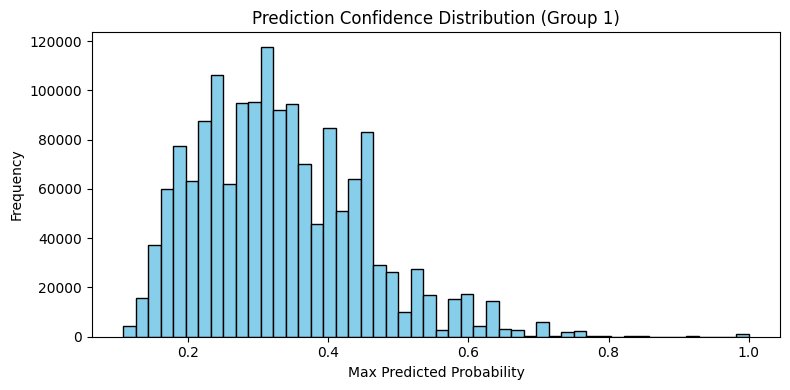

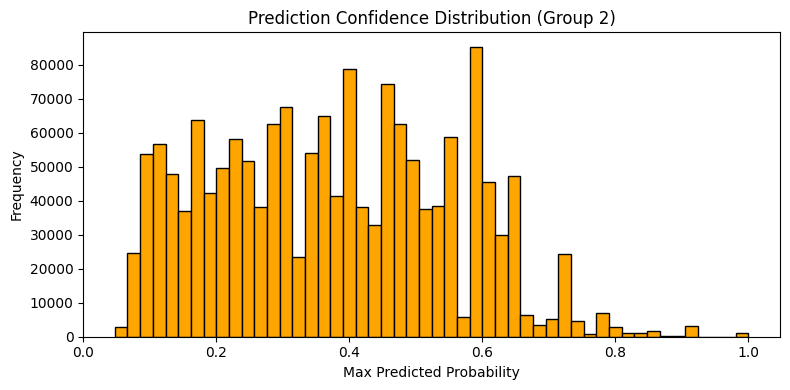

Low-confidence predictions (Group 1, prob < 0.7): 1577405 out of 1589760
Low-confidence predictions (Group 2, prob < 0.7): 1537913 out of 1589760


In [33]:

# Step 3: Reduce feature set
W_train = Train_new[:, :2]
Q_train = Train_new[:, -2:].astype(int)
print(W_train.shape)
print(Q_train.shape)

W_test = Test_new[:, :2]
Q_test = Test_new[:, -2:].astype(int)
print(W_test.shape)
print(Q_test.shape) 

# Step 5: Train classifiers
best_params = {
    "n_estimators": 500,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "max_depth": None,
    "n_jobs": -1,
    "random_state": 0
}

clf_group1 = RandomForestClassifier(**best_params)
clf_group2 = RandomForestClassifier(**best_params)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

# --- Enforce deterministic zero rule (column-wise) ---

mask_col0 = (W_test[:, 0] == 0)
mask_col1 = (W_test[:, 1] == 0)

# Force predictions
pred_group1[mask_col0] = 0
pred_group2[mask_col1] = 0

# Force probabilities
if np.any(mask_col0):
    k = np.sum(mask_col0)
    if proba_group1.shape[1] == 2:
        proba_group1[mask_col0] = np.tile([1.0, 0.0], (k, 1))
    else:  # degenerate case: only one class seen in training
        proba_group1[mask_col0] = 1.0

if np.any(mask_col1):
    k = np.sum(mask_col1)
    if proba_group2.shape[1] == 2:
        proba_group2[mask_col1] = np.tile([1.0, 0.0], (k, 1))
    else:
        proba_group2[mask_col1] = 1.0

# recompute max probs
max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 1, prob < 0.7): "
    f"{len(low_conf_indices1)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 2, prob < 0.7): "
    f"{len(low_conf_indices2)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)


<div class="alert alert-block alert-success">
<span style="font-size: 15pt;"><b>use PLOM output and train set predict group1,2 mineralID for IMAGE 4

In [3]:
# Path to the PLoMscript
script_path = '/Users/kmccoy/Documents/USC/Research/Dissertation/kelli_scripts/PLoM/plom.py'

# Load the module
spec = importlib.util.spec_from_file_location('plom', script_path)
plom = importlib.util.module_from_spec(spec)
sys.modules['plom'] = plom
spec.loader.exec_module(plom)

In [2]:
Plom_NMFsamp=np.load("/Users/kmccoy/Documents/USC/Research/Dissertation/Data/PLOMout_TOAKNNNMF_170ksamples.npy")
print("Sampled shape:", Plom_NMFsamp.shape)

Image4_all=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/Image4_pcaall.npy')
print("Image4_all shape:", Image4_all.shape)

Sampled shape: (170000, 22985)
Image4_all shape: (1, 22985)


In [4]:
wfile=Image4_all[:,:22485]
print(wfile.shape)

Q = np.arange(22485,22985)
print(Q.shape)

cond_cols = np.arange(0,22485)
print(cond_cols.shape)

expn, var=plom._conditional_expectation(Plom_NMFsamp,Q,cond_cols,wfile)
print(expn.shape)

plom_group1_cond=expn[:200]
print(plom_group1_cond.shape)
plom_group2_cond=expn[200:]
print(plom_group2_cond.shape)

(1, 22485)
(500,)
(22485,)

***********************************************************
Conditional expectation evaluation starting at 2025-09-29 15:45:34

Estimating the conditional expectation of <variable [22485 22486 22487 22488 22489 22490 22491 22492 22493 22494 22495 22496
 22497 22498 22499 22500 22501 22502 22503 22504 22505 22506 22507 22508
 22509 22510 22511 22512 22513 22514 22515 22516 22517 22518 22519 22520
 22521 22522 22523 22524 22525 22526 22527 22528 22529 22530 22531 22532
 22533 22534 22535 22536 22537 22538 22539 22540 22541 22542 22543 22544
 22545 22546 22547 22548 22549 22550 22551 22552 22553 22554 22555 22556
 22557 22558 22559 22560 22561 22562 22563 22564 22565 22566 22567 22568
 22569 22570 22571 22572 22573 22574 22575 22576 22577 22578 22579 22580
 22581 22582 22583 22584 22585 22586 22587 22588 22589 22590 22591 22592
 22593 22594 22595 22596 22597 22598 22599 22600 22601 22602 22603 22604
 22605 22606 22607 22608 22609 22610 22611 22612 22613 22614 2

In [5]:
H=np.load("/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_banddepthKNN_nmf_r200_basis.npy")
print("H shape:", H.shape)
W=plom_group1_cond.reshape(1,-1)
print("W shape:", W.shape)
g1_recon = W @ H
print("Reconstructed shape:", g1_recon.shape)

actual = Image4_all[:,22485:22685]
print("actual shape:",actual.shape)
g1_actual = actual @ H
print("Actual reconstructed shape:", g1_actual.shape)

H shape: (200, 1589760)
W shape: (1, 200)
Reconstructed shape: (1, 1589760)
actual shape: (1, 200)
Actual reconstructed shape: (1, 1589760)


In [6]:

# --- Reconstruct ---
# W = np.load("/path/group1_banddepth_nmf_r90_reduced.npy")
# H = np.load("/path/group1_banddepth_nmf_r90_basis.npy")
# X_recon = W @ H
H=np.load("/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_banddepthKNN_nmf_r300_basis.npy")
print("H shape:", H.shape)
W=plom_group2_cond.reshape(1,-1)
print("W shape:", W.shape)
g2_recon = W @ H
print("Reconstructed shape:", g2_recon.shape)

actual = Image4_all[:,22685:]
print("actual shape:",actual.shape)
g2_actual = actual @ H
print("Actual reconstructed shape:", g2_actual.shape)

H shape: (300, 1589760)
W shape: (1, 300)
Reconstructed shape: (1, 1589760)
actual shape: (1, 300)
Actual reconstructed shape: (1, 1589760)


In [14]:
#formulate an image pixel dataset with TOA reflectance, band depth features, and mineral IDs for image 4
#Image4=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOAref_image4_1589760x285.npy')
#print("Image shape:", Image4.shape)

gb1ID=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group1_mineralID.npy')
gb1ID_4=(gb1ID[4]).reshape(1,-1)
print(gb1ID_4.shape)

gb2ID=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/group2_mineralID.npy')
gb2ID_4=(gb2ID[4]).reshape(1,-1)
print(gb2ID_4.shape)

Test_new4=np.vstack((g1_recon,g2_recon,gb1ID_4,gb2ID_4)).T
print(Test_new4.shape)

np.save('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1_gb2_gb1ID_gb2ID_image4.npy',Test_new4)

(1, 1589760)
(1, 1589760)
(1589760, 4)


Train shape: (1260203, 4)
(1260203, 2)
(1260203, 2)
(1589760, 2)
(1589760, 2)

Group 1 Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00      1852
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.35      0.00       358
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          13       0.00      0.00      0.00      1418
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0
          16       0.00      0.01      0.01       255
          17       0.00      0.00      0.00         0
          19       0.00   

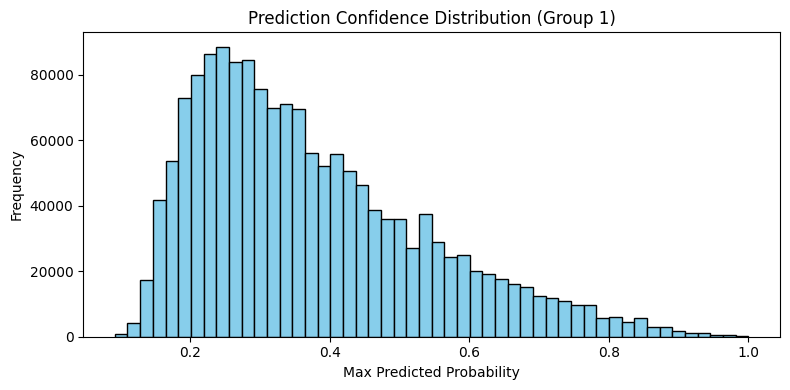

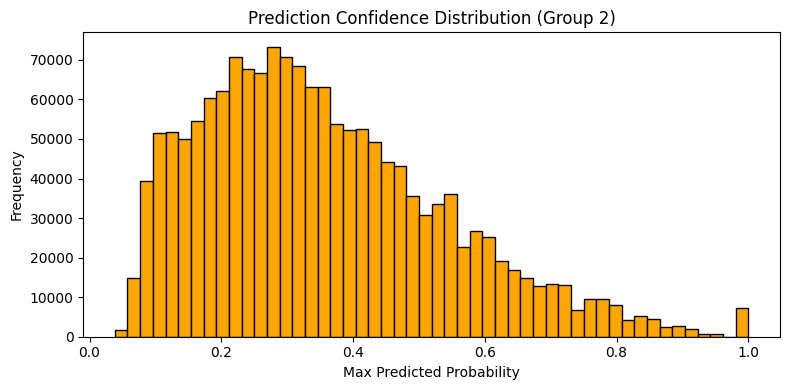

Low-confidence predictions (Group 1, prob < 0.7): 1507716 out of 1589760
Low-confidence predictions (Group 2, prob < 0.7): 1505154 out of 1589760


: 

In [ ]:
Train_all = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_balanced_W_gb1_gb2_gb1ID_gb2ID_train7500.npy')
Train_gb=Train_all[:,-4:-2]
Train_ID=Train_all[:,-2:].astype(int)
Train_new=np.hstack((Train_gb,Train_ID))
print("Train shape:", Train_new.shape)

# Step 3: Reduce feature set
W_train = Train_new[:, :2]
Q_train = Train_new[:, -2:].astype(int)
print(W_train.shape)
print(Q_train.shape)

W_test = Test_new4[:, :2]
Q_test = Test_new4[:, -2:].astype(int)
print(W_test.shape)
print(Q_test.shape) 

# Step 5: Train classifiers
best_params = {
    "n_estimators": 500,
    "min_samples_split": 10,
    "min_samples_leaf": 4,
    "max_features": "sqrt",
    "max_depth": None,
    "n_jobs": -1,
    "random_state": 0
}

clf_group1 = RandomForestClassifier(**best_params)
clf_group2 = RandomForestClassifier(**best_params)

clf_group1.fit(W_train, Q_train[:, 0])
clf_group2.fit(W_train, Q_train[:, 1])

# Step 6: Predict labels and probabilities
pred_group1 = clf_group1.predict(W_test)
pred_group2 = clf_group2.predict(W_test)

proba_group1 = clf_group1.predict_proba(W_test)
proba_group2 = clf_group2.predict_proba(W_test)

# --- Enforce deterministic zero rule (column-wise) ---

mask_col0 = (W_test[:, 0] == 0)
mask_col1 = (W_test[:, 1] == 0)

# Force predictions
pred_group1[mask_col0] = 0
pred_group2[mask_col1] = 0

# Force probabilities
if np.any(mask_col0):
    k = np.sum(mask_col0)
    if proba_group1.shape[1] == 2:
        proba_group1[mask_col0] = np.tile([1.0, 0.0], (k, 1))
    else:  # degenerate case: only one class seen in training
        proba_group1[mask_col0] = 1.0

if np.any(mask_col1):
    k = np.sum(mask_col1)
    if proba_group2.shape[1] == 2:
        proba_group2[mask_col1] = np.tile([1.0, 0.0], (k, 1))
    else:
        proba_group2[mask_col1] = 1.0

# recompute max probs
max_probs_group1 = np.max(proba_group1, axis=1)
max_probs_group2 = np.max(proba_group2, axis=1)

# Step 7: Evaluate
print("\nGroup 1 Classification Report")
print(classification_report(Q_test[:, 0], pred_group1, zero_division=0))

print("\nGroup 2 Classification Report")
print(classification_report(Q_test[:, 1], pred_group2, zero_division=0))

# Step 8: Confidence histograms
plt.figure(figsize=(8, 4))
plt.hist(max_probs_group1, bins=50, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 1)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(max_probs_group2, bins=50, color='orange', edgecolor='black')
plt.title("Prediction Confidence Distribution (Group 2)")
plt.xlabel("Max Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 9: Low-confidence predictions
low_conf_indices1 = np.where(max_probs_group1 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 1, prob < 0.7): "
    f"{len(low_conf_indices1)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group1knockoff.npy", low_conf_indices1)

low_conf_indices2 = np.where(max_probs_group2 < 0.7)[0]
print(
    f"Low-confidence predictions (Group 2, prob < 0.7): "
    f"{len(low_conf_indices2)} out of {len(W_test)}"
)
# np.save("low_confidence_indices_group2knockoff.npy", low_conf_indices2)


In [31]:
M=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/exp_Q_allfeat_gID_img4.npy')
print(M[:5, :])
# Round half up to nearest integer (works for negatives too)
rounded = np.floor(M + 0.5)
Img4ID_pred = rounded.astype(int)
print(Img4ID_pred[:5, :])

Img4ID_actual=np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1_gb2_gb1ID_gb2ID_image4.npy')
Img4ID_actual=Img4ID_actual[:,-2:].astype(int)
print(Img4ID_actual[:5, :])


[[ 53.37601848 191.66636341]
 [ 58.19047379 191.42365204]
 [ 57.51011578 191.45753858]
 [ 50.88811252 191.63262513]
 [ 51.48174426 191.65208783]]
[[ 53 192]
 [ 58 191]
 [ 58 191]
 [ 51 192]
 [ 51 192]]
[[ 47 192]
 [ 47 191]
 [ 47 191]
 [ 47 191]
 [ 47 191]]


Column 0 — Confusion Matrix (counts):
Pred    0   4   8   13  16  18  19  20  21  22  ...  67  68  69  70  71  72  \
Actual                                          ...                           
0        0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
4        0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
8        4   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
13       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
16       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
...     ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...  ..  ..  ..  ..  ..  ..   
72       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
73       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
74       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
75       0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
80       3   0

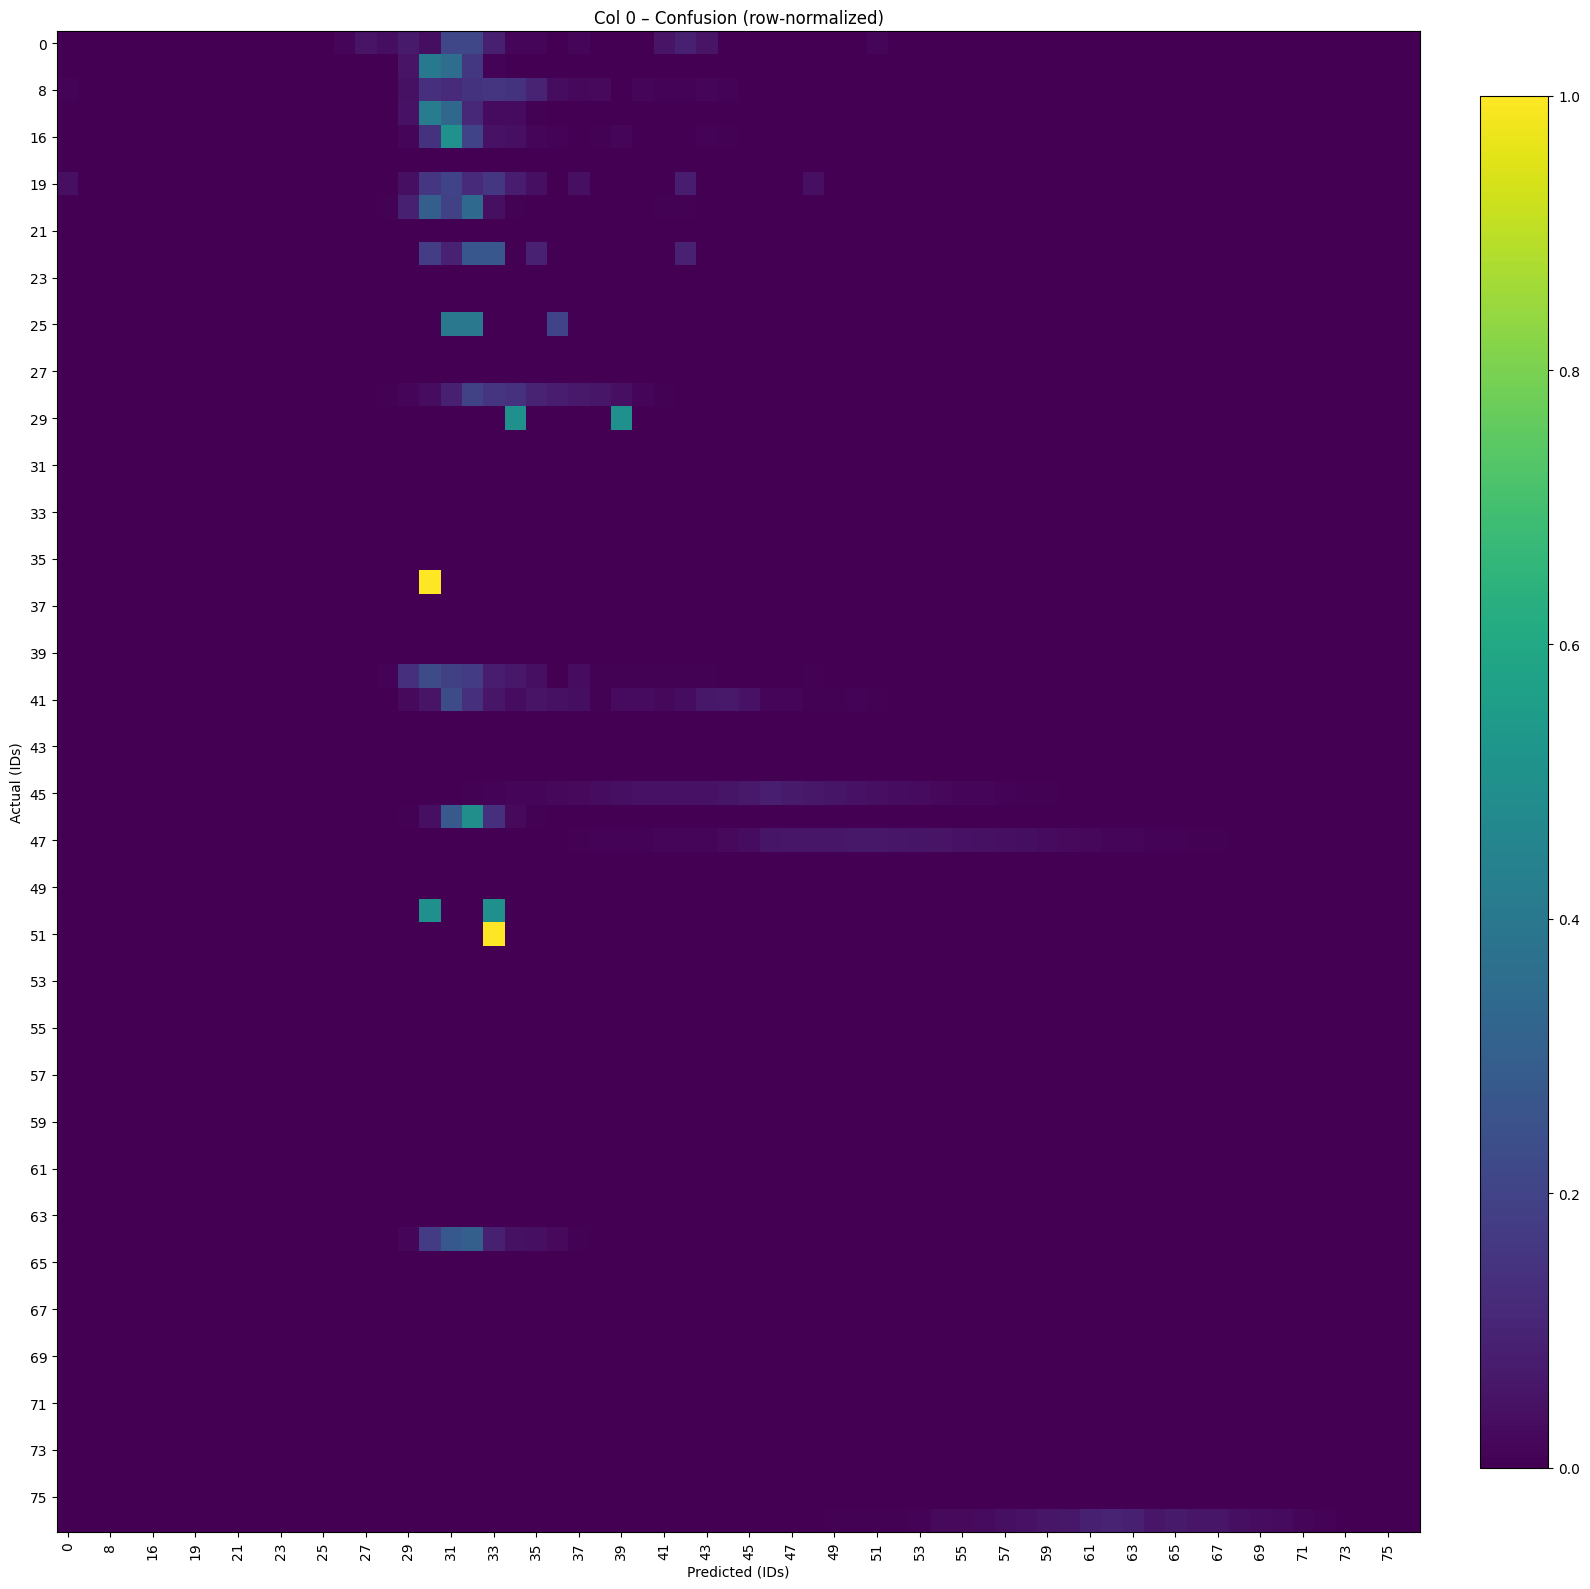

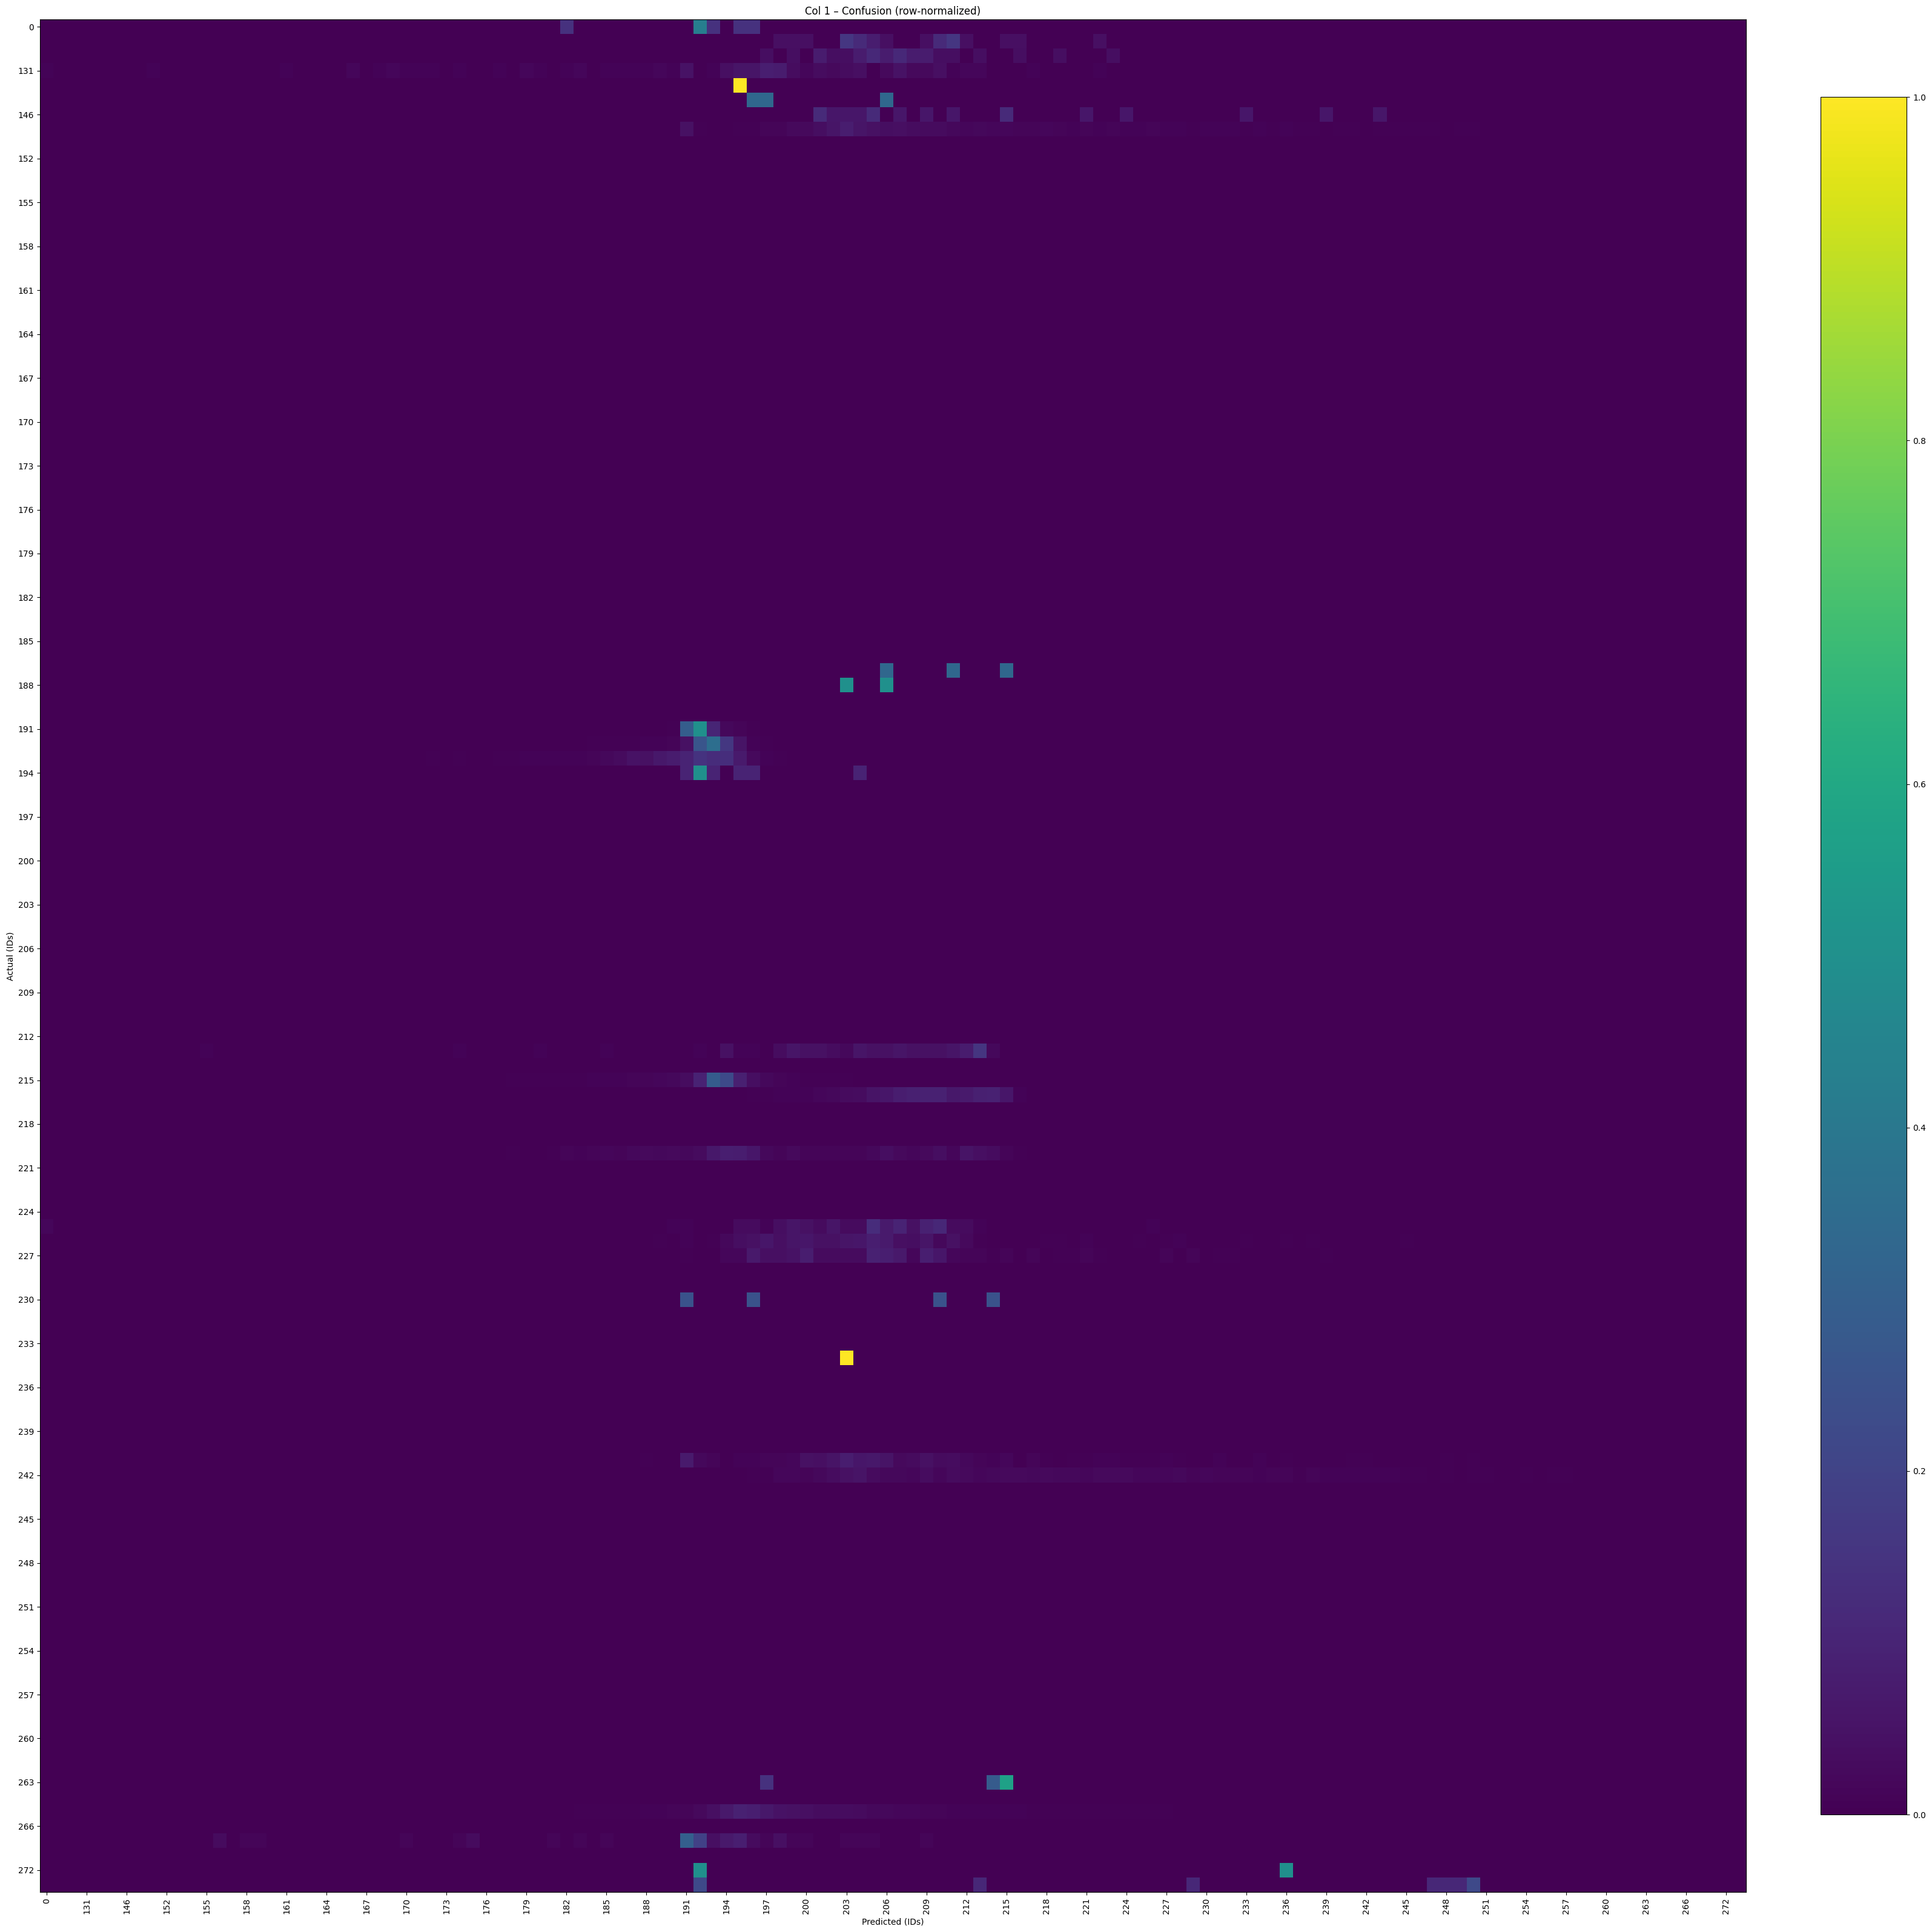

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# --- Load your arrays ---
# Preds (float, may contain NaNs); do half-up rounding but keep float so NaNs survive
P = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/exp_Q_allfeat_gID_img4.npy')
P = np.floor(P + 0.5)  # round half up

# Actuals (float or int; may contain NaNs)
A = np.load('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/TOApixel_W_gb1_gb2_gb1ID_gb2ID_image4.npy') 
A=A[:,-2:].astype(int)

# --- Ensure we have a 2D shape with last dim = features ---
# (e.g., if shape is (H, W, 2) or (N, 2), this reshapes to (?, 2))
P2 = P.reshape(-1, P.shape[-1])
A2 = A.reshape(-1, A.shape[-1])

def confusion_for_column(A2, P2, col):
    # Take column
    a = A2[:, col]
    p = P2[:, col]

    # Mask out NaNs in either
    mask = np.isfinite(a) & np.isfinite(p)
    a = a[mask].astype(int, copy=False)
    p = p[mask].astype(int, copy=False)

    # Labels present in either
    labels = np.unique(np.concatenate([a, p]))

    # Confusion matrix (counts)
    cm = confusion_matrix(a, p, labels=labels)
    cm_df = pd.DataFrame(cm, index=pd.Index(labels, name="Actual"),
                            columns=pd.Index(labels, name="Pred"))

    # Row-normalized
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums != 0)
    cm_norm_df = pd.DataFrame(cm_norm, index=pd.Index(labels, name="Actual"),
                                columns=pd.Index(labels, name="Pred"))

    acc = (a == p).mean() if a.size else float('nan')
    return cm_df, cm_norm_df, acc, labels

# --- Column 0 ---
cm0, cm0_norm, acc0, labels0 = confusion_for_column(A2, P2, 0)
print("Column 0 — Confusion Matrix (counts):")
print(cm0)
print("\nColumn 0 — Row-normalized:")
print(cm0_norm.round(3))
print(f"\nColumn 0 — Accuracy: {acc0:.4f}\n")

# --- Column 1 ---
cm1, cm1_norm, acc1, labels1 = confusion_for_column(A2, P2, 1)
print("Column 1 — Confusion Matrix (counts):")
print(cm1)
print("\nColumn 1 — Row-normalized:")
print(cm1_norm.round(3))
print(f"\nColumn 1 — Accuracy: {acc1:.4f}")


def show_heatmap_from_df(df, title, annotate_if_small=True, max_ticks=50):
    """
    df: pandas DataFrame whose index = Actual IDs, columns = Predicted IDs
    """
    vals = df.values
    rows, cols = df.index, df.columns

    # Figure size scales with number of labels
    fig_w = max(7, 0.25 * len(cols))
    fig_h = max(6, 0.25 * len(rows))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    im = ax.imshow(vals, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Predicted (IDs)')
    ax.set_ylabel('Actual (IDs)')

    # Choose ticks (sample if too many)
    def sampled_ticks(n, labels):
        if n <= max_ticks:
            idx = np.arange(n)
        else:
            step = int(np.ceil(n / max_ticks))
            idx = np.arange(0, n, step)
        return idx, [labels[i] for i in idx]

    xticks, xticklabels = sampled_ticks(len(cols), list(cols))
    yticks, yticklabels = sampled_ticks(len(rows), list(rows))

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Annotate cells if small enough
    if annotate_if_small and df.shape[0] <= 20 and df.shape[1] <= 20:
        is_float = np.issubdtype(vals.dtype, np.floating)
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                text = f"{vals[i, j]:.2f}" if is_float else str(int(vals[i, j]))
                ax.text(j, i, text, ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

# Row-normalized
show_heatmap_from_df(cm0_norm, "Col 0 – Confusion (row-normalized)")
show_heatmap_from_df(cm1_norm, "Col 1 – Confusion (row-normalized)")

<div class="alert alert-block alert-success">
<span style="font-size: 15pt;"><b>Attention trials

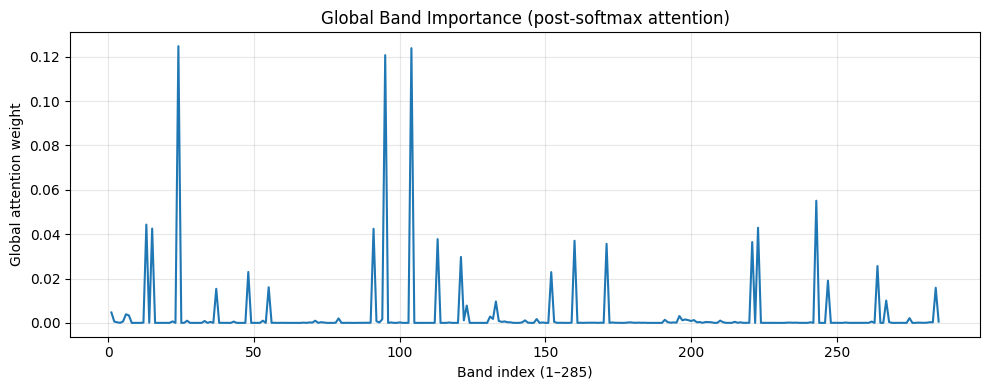

Sum of weights ≈ 1.000000
Top 20 bands by global attention:
 1. Band  24: 0.124717
 2. Band 104: 0.123816
 3. Band  95: 0.120665
 4. Band 243: 0.055066
 5. Band  13: 0.044306
 6. Band 223: 0.042890
 7. Band  15: 0.042507
 8. Band  91: 0.042418
 9. Band 113: 0.037760
10. Band 160: 0.037023
11. Band 221: 0.036428
12. Band 171: 0.035607
13. Band 121: 0.029725
14. Band 264: 0.025614
15. Band  48: 0.022949
16. Band 152: 0.022884
17. Band 247: 0.019052
18. Band  55: 0.016065
19. Band 284: 0.015833
20. Band  37: 0.015354


In [3]:
CSV_PATH=('/Users/kmccoy/Documents/USC/Research/Dissertation/Data/attn_reports_run1/band_attention_global.csv')
w = np.loadtxt(CSV_PATH, delimiter=",").reshape(-1)
assert w.size == 285, f"Expected 285 values, got {w.size}"

x = np.arange(1, 286)  # 1..285

plt.figure(figsize=(10, 4))
plt.plot(x, w)
plt.xlabel("Band index (1–285)")
plt.ylabel("Global attention weight")
plt.title("Global Band Importance (post-softmax attention)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sum of weights ≈ {w.sum():.6f}")

# Top-20 indices (descending), convert to 1-based band numbers
top_idx = np.argsort(w)[-20:][::-1]
top_bands_1based = top_idx + 1
top_vals = w[top_idx]

print("Top 20 bands by global attention:")
for rank, (b, v) in enumerate(zip(top_bands_1based, top_vals), 1):
    print(f"{rank:>2}. Band {b:>3}: {v:.6f}")

# Optional: keep as arrays for later use
top20 = np.column_stack([top_bands_1based, top_vals])






In [12]:
ATTN_PATH = "/Users/kmccoy/Documents/USC/Research/Dissertation/Data/attn_reports_run1/band_attention_by_class.csv"   # 96 x 285
MINERAL_CSV = "../Data/mineral_grouping_matrix_20230503.csv"
TOPK = 5

W = np.loadtxt(ATTN_PATH, delimiter=",")
assert W.shape == (95, 285), f"Expected (95,285), got {W.shape}"

# Load only Name & Group; filter to Group==1
df = pd.read_csv(MINERAL_CSV, usecols=lambda c: c.lower() in {"name","group"})
df.columns = [c.lower() for c in df.columns]
names_g1 = df.loc[df["group"] == 1, "name"].astype(str).to_list()
if len(names_g1) < 95:
    raise ValueError(f"Need at least 95 Group==1 Names; got {len(names_g1)}")

# Helper to print top-K for a row r with label
def print_topk(label, wrow):
    top = np.argsort(wrow)[-TOPK:][::-1]
    pairs = ", ".join(f"{b+1}:{wrow[b]:.6f}" for b in top)
    print(f"{label} -> {pairs}")


# Rows 1..95 with Group==1 Names (use first 95 names)
for r, name in zip(range(0, 95), names_g1[:95]):
    print_topk(name, W[r])


Plastic_Tarp GDS339 Green W1R1Fa -> 285:0.000000, 97:0.000000, 91:0.000000, 92:0.000000, 93:0.000000
Hematite.02+Quartz.98 GDS76 W1R1Ha -> 24:0.123584, 95:0.123013, 104:0.120080, 243:0.085717, 223:0.082869
Goethite WS222 <250um MedGrn W1R1H_ AREF -> 104:0.125694, 24:0.125165, 95:0.122193, 91:0.116033, 15:0.102632
Goethite0.02+Quartz GDS240 W1R1Ba -> 95:0.129972, 104:0.125227, 24:0.125185, 91:0.061757, 13:0.057313
Goethite MPCMA2-B FineGr adj W1R1Bb -> 95:0.129745, 104:0.125374, 24:0.125061, 15:0.080182, 13:0.079638
Goethite MPCMA2-C M-Crsgrad2 W1R1Hb AREF -> 95:0.125252, 104:0.125126, 24:0.125041, 91:0.085428, 13:0.075683
Goethite WS222 coarse grain W1R1H_ -> 104:0.125029, 24:0.125023, 95:0.109121, 91:0.097874, 13:0.070620
Goethite_Thin_Film WS222 W1R1Ba -> 95:0.137875, 104:0.125716, 24:0.125269, 13:0.054697, 243:0.052344
Goeth+qtz.5+Jarosite.5 AMX11 W1R1BbS -> 24:0.125138, 104:0.124904, 171:0.090790, 121:0.084636, 243:0.071554
Pyrite LV95-6A Weath on Tail W1R1Bb -> 24:0.126452, 104:0.

for given spectrum, find contributions from different minerals by projecting and normalizing. transform vector of spectra into vector of mineral composition. probability associated with mineral. take difference between probability of mineral. use difference in mineral composition. project x on W, then take norm

K(xi,xj)=exp(-1/h (xi-xj)^T W (x))= exp(-1/h  || W (xi-xj)||) --vector; projection. probability that xi associated with given mineral

TOA reflectance -R^Nx285; group band depth (1,2)- R^Nx2 ; group mineral ID (1,2)- R^Nx2)-integer value

95 d for each pixel. have whole cube. transform into mineral id data. use acutal data